# Introduction

For my final project, I performed an exploratory data analysis of arriving and departing flight information from Amsterdam Schiphol Airport’s public API. This project builds on my midterm project, where I analyzed one day of departing flight data. For the final project, I expanded the scope to approximately one month of both arrivals and departures, giving me a broader view of airport activity, delay patterns, airline behavior, and route-level operations.

The target audience for this analysis is airport operations management at Schiphol, as well as airline station managers who operate flights at the airport. These groups care about when airport activity is most concentrated, which airlines and route regions are most exposed to delays, how terminal and aircraft usage varies, and whether basic flight characteristics can help predict operational disruption. While this project is exploratory, the goal is to produce insights that could support staffing decisions, gate and terminal planning, airline coordination, and further investigation into delay management.

The original dataset contains detailed operational information, including flight numbers, scheduled times, actual arrival or departure times, terminals, gates, aircraft information, route information, and codeshare data. However, the raw API data required significant cleaning before it could be analyzed. Codeshare flights created duplicate rows, several columns contained nested or hard-to-read values, and some important fields such as airline, aircraft, country, and continent information needed to be clarified using outside datasets. To address this, I supplemented the Schiphol data with public airport, country, airline, and aircraft lookup datasets.

The project proceeds in three main stages. First, I clean and prepare the data by removing duplicate codeshare rows, engineering delay and time-based variables, improving terminal and service-type labels, and merging in additional route, airline, and aircraft information. Second, I conduct exploratory data analysis to examine flight volume, delay patterns, airline concentration, route geography, terminal usage, and aircraft usage. Third, I build two predictive models: a linear regression model to estimate delay minutes and a logistic regression model to classify whether a flight is delayed by at least 15 minutes. Together, the EDA and models are intended to show both what patterns exist in Schiphol’s operations and how much of those patterns can be predicted using the available data.

# Step 0 : loading necessary packages, importing the data from the API

As I explained in the API pull notebook, the size and speed of the Schiphol API limited my ability to pull the data and analyze it in the same notebook (it crashed the first time). Therefore, I am reading in a .csv file containing the data pulled in that separate notebook here.

In [130]:
# import the packages I need to perform an EDA and construct a linear regression model

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)

# import the data

flights = pd.read_csv("schiphol_arrivals_departures_last_month_clean.csv", low_memory=False)

print("Rows and columns:")
print(flights.shape)

display(flights.head())

# get a cursory view of what it looks like (i.e. column names)

for column in flights.columns:
    print(column)

Rows and columns:
(146563, 41)


,lastUpdatedAt,actualLandingTime,aircraftRegistration,estimatedLandingTime,expectedTimeOnBelt,flightDirection,flightName,flightNumber,gate,pier,id,isOperationalFlight,mainFlight,prefixIATA,prefixICAO,airlineCode,scheduleDateTime,scheduleDate,scheduleTime,serviceType,terminal,schemaVersion,aircraftType.iataMain,aircraftType.iataSub,baggageClaim.belts,publicFlightState.flightStates,route.destinations,route.eu,route.visa,codeshares.codeshares,expectedSecurityFilter,api_query_date,flight_direction,direction_label,actualOffBlockTime,checkinAllocations.checkinAllocations,expectedTimeBoarding,expectedTimeGateClosing,expectedTimeGateOpen,publicEstimatedOffBlockTime,transferPositions.transferPositions
0,2026-04-29T02:00:59.085+02:00,2026-04-29T00:20:21.000+02:00,PHYHY,2026-04-29T00:20:21.000+02:00,2026-04-29T01:26:39.433+02:00,A,HV5960,5960,Z02,Z,144812504121564240,True,HV5960,HV,TRA,164.0,2026-04-29T00:00:00.000+02:00,2026-04-29,00:00:00,J,3.0,4,32S,32Q,['16'],"['ARR', 'EXP']",['LIS'],S,False,NaN,NaN,2026-04-29,A,Arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-29T02:54:10.101+02:00,2026-04-29T00:16:49.000+02:00,PHHBK,2026-04-29T00:16:49.000+02:00,2026-04-29T00:59:10.309+02:00,A,HV6706,6706,D84,D,144812504121659638,True,HV6706,HV,TRA,164.0,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,J,3.0,4,737,73H,['18'],"['ARR', 'EXP']",['FUE'],S,False,NaN,NaN,2026-04-29,A,Arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-29T01:11:06.081+02:00,2026-04-28T23:38:34.000+02:00,PHHZI,2026-04-28T23:38:34.000+02:00,2026-04-29T00:07:29.000+02:00,A,HV6862,6862,D81,D,144812504121662812,True,HV6862,HV,TRA,164.0,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,J,1.0,4,737,73H,['4'],"['ARR', 'EXP']",['ATH'],S,False,NaN,NaN,2026-04-29,A,Arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-29T01:57:50.092+02:00,2026-04-29T00:33:43.000+02:00,PHHSB,2026-04-29T00:33:43.000+02:00,2026-04-29T00:54:42.000+02:00,A,HV5134,5134,C5,C,144812504121542122,True,HV5134,HV,TRA,164.0,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,J,1.0,4,737,73H,['6'],"['ARR', 'EXP']",['BCN'],S,False,NaN,NaN,2026-04-29,A,Arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-29T01:48:06.083+02:00,2026-04-29T00:03:52.000+02:00,PHYHU,2026-04-29T00:03:52.000+02:00,2026-04-29T00:38:31.000+02:00,A,HV5666,5666,Z07,Z,144812504121556038,True,HV5666,HV,TRA,164.0,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,J,1.0,4,32S,32Q,['4'],"['ARR', 'EXP']",['LPA'],S,False,['KL2573'],NaN,2026-04-29,A,Arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN


lastUpdatedAt
actualLandingTime
aircraftRegistration
estimatedLandingTime
expectedTimeOnBelt
flightDirection
flightName
flightNumber
gate
pier
id
isOperationalFlight
mainFlight
prefixIATA
prefixICAO
airlineCode
scheduleDateTime
scheduleDate
scheduleTime
serviceType
terminal
schemaVersion
aircraftType.iataMain
aircraftType.iataSub
baggageClaim.belts
publicFlightState.flightStates
route.destinations
route.eu
route.visa
codeshares.codeshares
expectedSecurityFilter
api_query_date
flight_direction
direction_label
actualOffBlockTime
checkinAllocations.checkinAllocations
expectedTimeBoarding
expectedTimeGateClosing
expectedTimeGateOpen
publicEstimatedOffBlockTime
transferPositions.transferPositions


Now we have a better sense of the information provided by the API, and can decide which columns will be most relevant to our analysis. What we can see, however, is that both the columns and the data contained therein are a mess! Let's get to cleaning.

In [131]:
# check for missing values

missing_table = pd.DataFrame({
    "missing_count": flights.isna().sum(),
    "missing_percent": flights.isna().mean() * 100
})

missing_table = missing_table.sort_values("missing_percent", ascending=False)

display(missing_table.head(41))

,missing_count,missing_percent
transferPositions.transferPositions,143096,97.634464
publicEstimatedOffBlockTime,130117,88.778887
expectedSecurityFilter,91432,62.384094
expectedTimeBoarding,88562,60.425892
expectedTimeGateOpen,88382,60.303078
expectedTimeGateClosing,87968,60.020605
checkinAllocations.checkinAllocations,75558,51.553257
expectedTimeOnBelt,75178,51.293983
baggageClaim.belts,75177,51.293300
actualOffBlockTime,75029,51.192320


I added this (above) in at the end of my cleaning process, because I noticed that the prefixIATA missing values count jumped from 4 to 18,512. This was likely an artifact of the merge, and I am going to add steps into those respective sections to prevent row duplication.

# Step 1 : clean the data & check for errors and/or missing values

Before we perform an EDA, we need to make sure that the data we have is clean and organized, and that errors and/or missing values are accounted for to prevent issues down the line!

### (a) First, we need to select the columns we want to keep in our dataframe:

In [132]:
# select columns:

columns_to_keep = [
    "prefixIATA",
    "flightName",
    "mainFlight",
    "isOperationalFlight",
    "flightDirection",
    "scheduleDateTime",
    "scheduleDate",
    "scheduleTime",
    "actualLandingTime",
    "actualOffBlockTime",
    "terminal",
    "gate",
    "serviceType",
    "aircraftType.iataMain",
    "aircraftType.iataSub",
    "aircraftRegistration",
    "route.destinations",
    "route.eu",
    "publicFlightState.flightStates",
    "codeshares.codeshares"
]

flights = flights[columns_to_keep].copy()

display(flights.head())

,prefixIATA,flightName,mainFlight,isOperationalFlight,flightDirection,scheduleDateTime,scheduleDate,scheduleTime,actualLandingTime,actualOffBlockTime,terminal,gate,serviceType,aircraftType.iataMain,aircraftType.iataSub,aircraftRegistration,route.destinations,route.eu,publicFlightState.flightStates,codeshares.codeshares
0,HV,HV5960,HV5960,True,A,2026-04-29T00:00:00.000+02:00,2026-04-29,00:00:00,2026-04-29T00:20:21.000+02:00,NaN,3.0,Z02,J,32S,32Q,PHYHY,['LIS'],S,"['ARR', 'EXP']",NaN
1,HV,HV6706,HV6706,True,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-29T00:16:49.000+02:00,NaN,3.0,D84,J,737,73H,PHHBK,['FUE'],S,"['ARR', 'EXP']",NaN
2,HV,HV6862,HV6862,True,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-28T23:38:34.000+02:00,NaN,1.0,D81,J,737,73H,PHHZI,['ATH'],S,"['ARR', 'EXP']",NaN
3,HV,HV5134,HV5134,True,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:33:43.000+02:00,NaN,1.0,C5,J,737,73H,PHHSB,['BCN'],S,"['ARR', 'EXP']",NaN
4,HV,HV5666,HV5666,True,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:03:52.000+02:00,NaN,1.0,Z07,J,32S,32Q,PHYHU,['LPA'],S,"['ARR', 'EXP']",['KL2573']


### (b) Then, we need to remove duplicate rows associated with codeshare flights. This was a problem I encountered during the midterm project. Schiphol Airport's API treats codeshare flight numbers as separate entries (rows) even when they are not actually the operating flight. We can remove these as duplicates and simplify the codeshare column to display only the number of different codeshare flights attached to the operating flight.

In [133]:
# remove codeshare duplicates

print("Rows before removing codeshare duplicates:", len(flights))

flights = flights[
    flights["flightName"] == flights["mainFlight"]
].copy()

flights = flights.reset_index(drop=True)

print("Rows after removing codeshare duplicates:", len(flights))

display(flights.head())

# simplify data expressed in codeshare column using a function, then applying it to the existing codeshares.codeshares column

def count_codeshares(codeshare_value):
    if pd.isna(codeshare_value):
        return 0
    
    codeshare_value = str(codeshare_value)
    
    codeshare_value = codeshare_value.replace("[", "")
    codeshare_value = codeshare_value.replace("]", "")
    codeshare_value = codeshare_value.replace("'", "")
    codeshare_value = codeshare_value.replace('"', "")
    
    if codeshare_value.strip() == "":
        return 0
    
    codeshare_list = codeshare_value.split(",")
    
    return len(codeshare_list)

flights["codeshares.codeshares"] = flights["codeshares.codeshares"].apply(count_codeshares)

display(flights[[
    "flightName",
    "mainFlight",
    "codeshares.codeshares"
]].head(20))

Rows before removing codeshare duplicates: 146563
Rows after removing codeshare duplicates: 42494


,prefixIATA,flightName,mainFlight,isOperationalFlight,flightDirection,scheduleDateTime,scheduleDate,scheduleTime,actualLandingTime,actualOffBlockTime,terminal,gate,serviceType,aircraftType.iataMain,aircraftType.iataSub,aircraftRegistration,route.destinations,route.eu,publicFlightState.flightStates,codeshares.codeshares
0,HV,HV5960,HV5960,True,A,2026-04-29T00:00:00.000+02:00,2026-04-29,00:00:00,2026-04-29T00:20:21.000+02:00,NaN,3.0,Z02,J,32S,32Q,PHYHY,['LIS'],S,"['ARR', 'EXP']",NaN
1,HV,HV6706,HV6706,True,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-29T00:16:49.000+02:00,NaN,3.0,D84,J,737,73H,PHHBK,['FUE'],S,"['ARR', 'EXP']",NaN
2,HV,HV6862,HV6862,True,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-28T23:38:34.000+02:00,NaN,1.0,D81,J,737,73H,PHHZI,['ATH'],S,"['ARR', 'EXP']",NaN
3,HV,HV5134,HV5134,True,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:33:43.000+02:00,NaN,1.0,C5,J,737,73H,PHHSB,['BCN'],S,"['ARR', 'EXP']",NaN
4,HV,HV5666,HV5666,True,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:03:52.000+02:00,NaN,1.0,Z07,J,32S,32Q,PHYHU,['LPA'],S,"['ARR', 'EXP']",['KL2573']


,flightName,mainFlight,codeshares.codeshares
0,HV5960,HV5960,0
1,HV6706,HV6706,0
2,HV6862,HV6862,0
3,HV5134,HV5134,0
4,HV5666,HV5666,1
5,HV6118,HV6118,0
6,HV5352,HV5352,1
7,HV5766,HV5766,0
8,HV6146,HV6146,1
9,HV5080,HV5080,0


(b)(i) It's unsurprising that this removed a TON of rows; some flights, for example, have as many as 7 different codeshare numbers attached to them! That single flight alone would account for 7 duplicate rows. Nevertheless, we're still left with over 42,000 flights to work with! That's a lot.

(NOTE) The 'rows after removal' value of 42,494 is the barometer we will use to identify row duplication incidents that result from merges going forward.

### (c) Now that we've cleaned up the codesharing information, we can move on - I need to clean up the destinations column, as it currently looks like a dictionary. This will also help me add more destination information later on, when I import another dataset to clarify this information!

In [134]:
# clean up the destinations using a function, then applying it to the existing destinations column

def get_first_airport(route_value):
    if pd.isna(route_value):
        return np.nan
    
    route_value = str(route_value)
    route_value = route_value.replace("[", "")
    route_value = route_value.replace("]", "")
    route_value = route_value.replace("'", "")
    route_value = route_value.replace('"', "")
    
    airports = route_value.split(",")
    first_airport = airports[0].strip()
    
    return first_airport

flights["route_airport"] = flights["route.destinations"].apply(get_first_airport)

display(flights[["route.destinations", "route_airport"]].head())

,route.destinations,route_airport
0,['LIS'],LIS
1,['FUE'],FUE
2,['ATH'],ATH
3,['BCN'],BCN
4,['LPA'],LPA


#### (1) Great! Now I can import an additional dataset to provide more information about where these aircraft are coming from/going to.

In [135]:
# add in the dataset

airports = pd.read_csv(
    "https://davidmegginson.github.io/ourairports-data/airports.csv",
    keep_default_na=False
)
display(airports.head())

# keep the useful columns from this dataset (especially IATA code), clean it a little (remove duplicate and missing values)

airports = pd.read_csv("https://davidmegginson.github.io/ourairports-data/airports.csv")

airport_lookup = airports[[
    "iata_code",
    "name",
    "municipality",
    "iso_country",
    "continent"
]].copy()

airport_lookup = airport_lookup.dropna(subset=["iata_code"])

airport_lookup["iata_code"] = airport_lookup["iata_code"].astype(str).str.strip().str.upper()

airport_lookup = airport_lookup.drop_duplicates(subset=["iata_code"])

display(airport_lookup.head())

# merge the data into the existing flights dataframe; merge on route.destinations and iata_code

flights = flights.merge(
    airport_lookup,
    left_on="route_airport",
    right_on="iata_code",
    how="left"
)

flights = flights.rename(columns={
    "name": "route_airport_name",
    "municipality": "route_city",
    "iso_country": "route_country",
    "continent": "route_continent"
})

display(flights[[
    "route_airport",
    "route_airport_name",
    "route_country",
    "route_city",
    "route_continent"
]].head())

# add a second new dataset and dictionary to make country & continent information readable

# countries first

countries = pd.read_csv(
    "https://davidmegginson.github.io/ourairports-data/countries.csv",
    keep_default_na=False
)
display(countries.head())

country_lookup = countries[[
    "code",
    "name",
]].copy()

country_lookup = country_lookup.rename(columns={
    "code": "route_country",
    "name": "route_country_name",
})

display(country_lookup.head())

flights = flights.merge(
    country_lookup,
    on="route_country",
    how="left"
)

display(flights[[
    "route_airport",
    "route_airport_name",
    "route_country",
    "route_country_name",
    "route_continent"
]].head(20))

# then continents

continent_map = {
    "AF": "Africa",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "SA": "South America",
    "OC": "Oceania",
}

flights["route_continent_name"] = flights["route_continent"].map(continent_map)
flights["route_continent_name"] = flights["route_continent_name"].fillna("Unknown")

# accounting for the error in North America

north_america_countries = [
    "United States",
    "Canada",
    "Mexico",
    "Aruba",
    "Bahamas",
    "Barbados",
    "Bermuda",
    "Bonaire, Sint Eustatius and Saba",
    "Caribbean Netherlands",
    "Cayman Islands",
    "Costa Rica",
    "Cuba",
    "Curaçao",
    "Dominican Republic",
    "Guadeloupe",
    "Jamaica",
    "Martinique",
    "Panama",
    "Puerto Rico",
    "Sint Maarten",
    "Trinidad and Tobago"
]

flights.loc[
    (flights["route_continent_name"] == "Unknown") &
    (flights["route_country_name"].isin(north_america_countries)),
    "route_continent_name"
] = "North America"

# drop redundant or non-useful columns

flights = flights.drop(
    columns=[
        "iata_code",
        "route_city",
        "route_country",
        "route_continent",
        "route.destinations",
        "route.eu",
        "publicFlightState.flightStates",
        "isOperationalFlight",
        "mainFlight",
        "aircraftType.iataMain"
    ],
    errors="ignore"
)

display(flights.head())
print(flights.shape)


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11,NA,US,US-PA,Bensalem,no,,,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,,
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435,NA,US,US-KS,Leoti,no,,,00AA,00AA,,,
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450,NA,US,US-AK,Anchor Point,no,,,00AK,00AK,,,
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820,NA,US,US-AL,Harvest,no,,,00AL,00AL,,,
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80,NA,US,US-AK,King Salmon,no,,,00AN,00AN,,,


,iata_code,name,municipality,iso_country,continent
204,UTK,Utirik Airport,Utirik Island,MH,OC
411,OCA,Ocean Reef Club Airport,Key Largo,US,NaN
634,CSE,Crested Butte Airpark,Crested Butte,US,NaN
891,CUS,Columbus Airport,Columbus,US,NaN
988,JCY,LBJ Ranch Airport,Stonewall,US,NaN


,route_airport,route_airport_name,route_country,route_city,route_continent
0,LIS,Lisbon Humberto Delgado Airport,PT,Lisbon,EU
1,FUE,Fuerteventura Airport,ES,El Matorral,AF
2,ATH,Athens Eleftherios Venizelos International Air...,GR,Spata-Artemida,EU
3,BCN,Josep Tarradellas Barcelona-El Prat Airport,ES,Barcelona,EU
4,LPA,Gran Canaria Airport,ES,Gran Canaria Island,AF


,id,code,name,continent,wikipedia_link,keywords
0,302672,AD,Andorra,EU,https://en.wikipedia.org/wiki/Andorra,Andorran airports
1,302618,AE,United Arab Emirates,AS,https://en.wikipedia.org/wiki/United_Arab_Emir...,"UAE,مطارات في الإمارات العربية المتحدة"
2,302619,AF,Afghanistan,AS,https://en.wikipedia.org/wiki/Afghanistan,
3,302722,AG,Antigua and Barbuda,NA,https://en.wikipedia.org/wiki/Antigua_and_Barbuda,Antiguan airports
4,302723,AI,Anguilla,NA,https://en.wikipedia.org/wiki/Anguilla,


,route_country,route_country_name
0,AD,Andorra
1,AE,United Arab Emirates
2,AF,Afghanistan
3,AG,Antigua and Barbuda
4,AI,Anguilla


,route_airport,route_airport_name,route_country,route_country_name,route_continent
0,LIS,Lisbon Humberto Delgado Airport,PT,Portugal,EU
1,FUE,Fuerteventura Airport,ES,Spain,AF
2,ATH,Athens Eleftherios Venizelos International Air...,GR,Greece,EU
3,BCN,Josep Tarradellas Barcelona-El Prat Airport,ES,Spain,EU
4,LPA,Gran Canaria Airport,ES,Spain,AF
5,AGP,Málaga-Costa del Sol Airport,ES,Spain,EU
6,FAO,Faro - Gago Coutinho International Airport,PT,Portugal,EU
7,GRO,Girona-Costa Brava Airport,ES,Spain,EU
8,ALC,Alicante-Elche Miguel Hernández Airport,ES,Spain,EU
9,RHO,"Rhodes International Airport ""Diagoras""",GR,Greece,AS


,prefixIATA,flightName,flightDirection,scheduleDateTime,scheduleDate,scheduleTime,actualLandingTime,actualOffBlockTime,terminal,gate,serviceType,aircraftType.iataSub,aircraftRegistration,codeshares.codeshares,route_airport,route_airport_name,route_country_name,route_continent_name
0,HV,HV5960,A,2026-04-29T00:00:00.000+02:00,2026-04-29,00:00:00,2026-04-29T00:20:21.000+02:00,NaN,3.0,Z02,J,32Q,PHYHY,0,LIS,Lisbon Humberto Delgado Airport,Portugal,Europe
1,HV,HV6706,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-29T00:16:49.000+02:00,NaN,3.0,D84,J,73H,PHHBK,0,FUE,Fuerteventura Airport,Spain,Africa
2,HV,HV6862,A,2026-04-29T00:05:00.000+02:00,2026-04-29,00:05:00,2026-04-28T23:38:34.000+02:00,NaN,1.0,D81,J,73H,PHHZI,0,ATH,Athens Eleftherios Venizelos International Air...,Greece,Europe
3,HV,HV5134,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:33:43.000+02:00,NaN,1.0,C5,J,73H,PHHSB,0,BCN,Josep Tarradellas Barcelona-El Prat Airport,Spain,Europe
4,HV,HV5666,A,2026-04-29T00:15:00.000+02:00,2026-04-29,00:15:00,2026-04-29T00:03:52.000+02:00,NaN,1.0,Z07,J,32Q,PHYHU,1,LPA,Gran Canaria Airport,Spain,Africa


(42494, 18)


That was a lot of code to work through. To make the information in the dataframe easier to understand for a wider audience, I added some relevant information - instead of displaying an IATA code for the destination, I've added more airport, country, and continent information for (1) laypeople and (2) more EDA opportunity. Then, I took the opportunity to remove redundant columns (i.e. route_airport and iata_code displayed the same information) and other columns that are no longer relevant to the EDA. I'm going to another dataset in a little while to clarify the airline codes and aircraft types, but will take a break from that for now. The airport stuff was a lot of work.

### (d) The next thing to clean are the time-related columns, because frankly, they're a mess! We can drop the scheduleDate and scheduleTime columns because they're already baked into the scheduleDateTime column.

In [136]:
flights["scheduleDateTime"] = pd.to_datetime(
    flights["scheduleDateTime"],
    errors="coerce"
)

flights["actualLandingTime"] = pd.to_datetime(
    flights["actualLandingTime"],
    errors="coerce"
)

flights["actualOffBlockTime"] = pd.to_datetime(
    flights["actualOffBlockTime"],
    errors="coerce"
)

flights = flights.drop(
    columns=[
        "scheduleDate",
        "scheduleTime"
    ],
    errors="ignore"
)

flights.head()

,prefixIATA,flightName,flightDirection,scheduleDateTime,actualLandingTime,actualOffBlockTime,terminal,gate,serviceType,aircraftType.iataSub,aircraftRegistration,codeshares.codeshares,route_airport,route_airport_name,route_country_name,route_continent_name
0,HV,HV5960,A,2026-04-29 00:00:00+02:00,2026-04-29 00:20:21+02:00,NaT,3.0,Z02,J,32Q,PHYHY,0,LIS,Lisbon Humberto Delgado Airport,Portugal,Europe
1,HV,HV6706,A,2026-04-29 00:05:00+02:00,2026-04-29 00:16:49+02:00,NaT,3.0,D84,J,73H,PHHBK,0,FUE,Fuerteventura Airport,Spain,Africa
2,HV,HV6862,A,2026-04-29 00:05:00+02:00,2026-04-28 23:38:34+02:00,NaT,1.0,D81,J,73H,PHHZI,0,ATH,Athens Eleftherios Venizelos International Air...,Greece,Europe
3,HV,HV5134,A,2026-04-29 00:15:00+02:00,2026-04-29 00:33:43+02:00,NaT,1.0,C5,J,73H,PHHSB,0,BCN,Josep Tarradellas Barcelona-El Prat Airport,Spain,Europe
4,HV,HV5666,A,2026-04-29 00:15:00+02:00,2026-04-29 00:03:52+02:00,NaT,1.0,Z07,J,32Q,PHYHU,1,LPA,Gran Canaria Airport,Spain,Africa


### (e) Next, we can engineer some flight status tracking features, since this would be an interesting aspect of airport operations to analyze, especially when examined in tandem with other categorical variables, like airline or time of day. To do this, I'm going ot adhere to the IATA's official delay threshold, which is 15 minutes – when a flight departs 15 minutes or more past its scheduled departure time, it's delayed. Similarly, if a flight arrives 15 minutes or more before its scheduled arrival time, it's early. All other flights are on-time (unless NaN). Once the feature has been created, I'm going to remove outliers (delays > 12 hours) by assigning them the average delay value for the non-outlier set.

In [137]:
# using actualLandingTime for arrivals and actualOffBlockTime for departures

flights["actual_time"] = flights["actualLandingTime"]

departure_rows = flights["flightDirection"] == "D"

flights.loc[departure_rows, "actual_time"] = flights.loc[
    departure_rows,
    "actualOffBlockTime"
]

# calculate delay in rounded (integer) minutes, since the decimal places clutter the table and are generally irrelevant

flights["delay_minutes"] = (
    (flights["actual_time"] - flights["scheduleDateTime"])
    .dt.total_seconds() / 60
).round().astype("Int64")


# create a status classification system based on the IATA's official guidelines

def classify_flight_status(delay):
    if pd.isna(delay):
        return "Unknown"
    elif delay >= 15:
        return "Delayed"
    elif delay <= -15:
        return "Early"
    else:
        return "On-time"

# apply the function to the information in the dataframe

flights["flight_status"] = flights["delay_minutes"].apply(classify_flight_status)

display(flights[[
    "flightDirection",
    "scheduleDateTime",
    "actual_time",
    "delay_minutes",
    "flight_status"
]].head(20))

# remove outliers

delay_outlier_rows = (
    flights["delay_minutes"].notna() &
    (flights["delay_minutes"] > 720)
)

print("Delay outliers above 12 hours:", delay_outlier_rows.sum())

average_delay_without_outliers = flights.loc[
    flights["delay_minutes"].notna() &
    (flights["delay_minutes"] <= 720),
    "delay_minutes"
].mean()

average_delay_without_outliers = round(average_delay_without_outliers)

print("Average delay without outliers:", average_delay_without_outliers)

flights.loc[
    delay_outlier_rows,
    "delay_minutes"
] = average_delay_without_outliers

flights["delay_minutes"] = flights["delay_minutes"].astype("Int64")

# check it

print("Largest delay after outlier adjustment:")
print(flights["delay_minutes"].max())

# re-perform the classification

flights["flight_status"] = flights["delay_minutes"].apply(classify_flight_status)

display(flights["flight_status"].value_counts(dropna=False))

,flightDirection,scheduleDateTime,actual_time,delay_minutes,flight_status
0,A,2026-04-29 00:00:00+02:00,2026-04-29 00:20:21+02:00,20,Delayed
1,A,2026-04-29 00:05:00+02:00,2026-04-29 00:16:49+02:00,12,On-time
2,A,2026-04-29 00:05:00+02:00,2026-04-28 23:38:34+02:00,-26,Early
3,A,2026-04-29 00:15:00+02:00,2026-04-29 00:33:43+02:00,19,Delayed
4,A,2026-04-29 00:15:00+02:00,2026-04-29 00:03:52+02:00,-11,On-time
5,A,2026-04-29 00:15:00+02:00,2026-04-29 02:55:13+02:00,160,Delayed
6,A,2026-04-29 00:20:00+02:00,2026-04-29 01:04:13+02:00,44,Delayed
7,A,2026-04-29 00:20:00+02:00,2026-04-29 00:14:57+02:00,-5,On-time
8,A,2026-04-29 00:20:00+02:00,2026-04-28 23:54:26+02:00,-26,Early
9,A,2026-04-29 00:30:00+02:00,2026-04-29 00:49:49+02:00,20,Delayed


Delay outliers above 12 hours: 21
Average delay without outliers: 5
Largest delay after outlier adjustment:
716


flight_status
On-time    24548
Delayed     9217
Early       6859
Unknown     1870
Name: count, dtype: int64

### (f) Similarly, we can feature engineer a time-of-day add-on can give me a better understanding of flight patterns at Schiphol on a macro and airline-focused level. First, I can create an hour-of-the-day and day-of-the-week feature; then, I can use this information to group flights into periods of the day (i.e. 'evening').

In [138]:
# first create hour and day feature

flights["scheduled_hour"] = flights["scheduleDateTime"].dt.hour
flights["scheduled_day"] = flights["scheduleDateTime"].dt.day_name()

flights["is_weekend"] = flights["scheduled_day"].isin(["Saturday", "Sunday"])

flights["is_weekend"] = flights["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

display(flights[["scheduled_day", "is_weekend"]].head())
display(flights[["scheduleDateTime", "scheduled_hour", "scheduled_day", "is_weekend"]].head())

# then add period feature

def get_time_of_day(hour):
    if pd.isna(hour):
        return "Unknown"
    elif hour < 6:
        return "Overnight"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

flights["time_of_day"] = flights["scheduled_hour"].apply(get_time_of_day)

display(flights[["scheduled_hour", "time_of_day"]].head())

,scheduled_day,is_weekend
0,Wednesday,Weekday
1,Wednesday,Weekday
2,Wednesday,Weekday
3,Wednesday,Weekday
4,Wednesday,Weekday


,scheduleDateTime,scheduled_hour,scheduled_day,is_weekend
0,2026-04-29 00:00:00+02:00,0,Wednesday,Weekday
1,2026-04-29 00:05:00+02:00,0,Wednesday,Weekday
2,2026-04-29 00:05:00+02:00,0,Wednesday,Weekday
3,2026-04-29 00:15:00+02:00,0,Wednesday,Weekday
4,2026-04-29 00:15:00+02:00,0,Wednesday,Weekday


,scheduled_hour,time_of_day
0,0,Overnight
1,0,Overnight
2,0,Overnight
3,0,Overnight
4,0,Overnight


### (g) Next, (yes, I know this is nit-picking) I want to clean up the terminal information. Currently, the values in the column are floats - I want to change them to just integer values (or even strings), since they are a categorical variable.

In [139]:
# use map to modify the values in the terminal column 

terminal_names = {
    1.0: "Terminal 1",
    2.0: "Terminal 2",
    3.0: "Terminal 3",
    4.0: "Terminal 4"
}

flights["terminal"] = flights["terminal"].map(terminal_names)

flights["terminal"] = flights["terminal"].fillna("Unknown")

display(flights[["terminal"]].head())

print(flights.shape)

,terminal
0,Terminal 3
1,Terminal 3
2,Terminal 1
3,Terminal 1
4,Terminal 1


(42494, 23)


### (h) Now I can return to importing new datasets to make sense of some of the information in the flights dataframe, since this is a public repo and my work will (hypothetically) be viewed/used by other people. I'm going to import two datasets from OpenFlights (public API resource) to better explain (1) airline codes and (2) aircraft codes. 

In [140]:
# first, import the dataset to decipher airline code values

airline_columns = [
    "airline_id",
    "airline_name",
    "airline_alias",
    "airline_iata_code",
    "airline_icao_code",
    "airline_callsign",
    "airline_country",
    "airline_active"
]

airlines = pd.read_csv(
    "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airlines.dat",
    header=None,
    names=airline_columns,
    na_values="\\N"
)

# keep only the columns that we want (IATA to merge, name to add) 

airlines = airlines[[
    "airline_name",
    "airline_iata_code"
]].copy()

display(airlines.head())

# drop missing values to prevent massive row duplication mishap

airlines = airlines.dropna(subset=["airline_iata_code"])

# make sure the data type is compatible with the existing flights df

airlines["airline_iata_code"] = airlines["airline_iata_code"].astype(str).str.strip().str.upper()

display(airlines.head())

# do the same for the df and then merge

flights["prefixIATA"] = flights["prefixIATA"].astype(str).str.strip().str.upper()

airlines = airlines.drop_duplicates(subset=["airline_iata_code"])

flights = flights.merge(
    airlines,
    left_on="prefixIATA",
    right_on="airline_iata_code",
    how="left"
)

display(flights[[
    "prefixIATA",
    "airline_name"
]].head(20))

# check for missing airlines

missing_airline_names = flights[
    flights["prefixIATA"].notna() &
    flights["airline_name"].isna()
]

print("Rows missing airline name:", len(missing_airline_names))

display(missing_airline_names[[
    "prefixIATA"
]].drop_duplicates().head(20))

print(flights.shape)

,airline_name,airline_iata_code
0,Unknown,-
1,Private flight,-
2,135 Airways,NaN
3,1Time Airline,1T
4,2 Sqn No 1 Elementary Flying Training School,NaN


,airline_name,airline_iata_code
0,Unknown,-
1,Private flight,-
3,1Time Airline,1T
10,40-Mile Air,Q5
13,Ansett Australia,AN


,prefixIATA,airline_name
0,HV,Transavia Holland
1,HV,Transavia Holland
2,HV,Transavia Holland
3,HV,Transavia Holland
4,HV,Transavia Holland
5,HV,Transavia Holland
6,HV,Transavia Holland
7,HV,Transavia Holland
8,HV,Transavia Holland
9,HV,Transavia Holland


Rows missing airline name: 1


,prefixIATA
17458,YU


(42494, 25)


This merge turned out to be a huge problem for me. Because some of the raw data had missing prefixIATA values (4 rows of nearly 150,000), it caused massive duplication when I merged the airline dataset into the flights dataframe, resulting in the addition of nearly 20,000 rows. I used ChatGPT to help me fix this problem; it recommended adding two lines that dropped missing values and duplicates, which worked. Now the code is fixed!

#### (1) Fixing an error I found in the display above; also, adding the missing 'YU' value. The imported dataset mistakenly classifies the IATA code CD as Alliance Air, when it should be Corendon Dutch Airlines. This is a relevant fix, since Corendon's main hub is at Schiphol Airport. I will be fixing other errors I find like this here as well.

In [141]:
flights.loc[flights["prefixIATA"] == "CD", "airline_name"] = "Corendon Dutch Airlines"
flights.loc[flights["prefixIATA"] == "EC", "airline_name"] = "easyJet Europe"
flights.loc[flights["prefixIATA"] == "VY", "airline_name"] = "Vueling Airlines"
flights.loc[flights["prefixIATA"] == "PC", "airline_name"] = "Pegasus Airlines"
flights.loc[flights["prefixIATA"] == "D8", "airline_name"] = "Norwegian Air Shuttle Sweden"
flights.loc[flights["prefixIATA"] == "VF", "airline_name"] = "AJet"

flights.loc[
    flights["prefixIATA"] == "YU",
    "airline_name"
] = "euroAtlantic Airways"

display(flights[[
    "prefixIATA",
    "airline_name"
]][flights["prefixIATA"] == "YU"].drop_duplicates())

,prefixIATA,airline_name
17458,YU,euroAtlantic Airways


In [142]:
# second, import the dataset to decipher aircraft codes

aircraft_columns = [
    "aircraft_name",
    "aircraft_iata_code",
    "aircraft_icao_code"
]

aircraft_lookup = pd.read_csv(
    "https://raw.githubusercontent.com/jpatokal/openflights/master/data/planes.dat",
    header=None,
    names=aircraft_columns,
    na_values="\\N"
)

# keep the columns I want

aircraft_lookup = aircraft_lookup[[
    "aircraft_name",
    "aircraft_iata_code"
]].copy()

display(aircraft_lookup.head())

# prevent merge duplication mishap part ii

aircraft_lookup = aircraft_lookup.dropna(subset=["aircraft_iata_code"])

# make sure the data typing conventions are compatible to be merged

aircraft_lookup["aircraft_iata_code"] = (
    aircraft_lookup["aircraft_iata_code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

flights["aircraftType.iataSub"] = (
    flights["aircraftType.iataSub"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# merge

aircraft_lookup = aircraft_lookup.drop_duplicates(
    subset=["aircraft_iata_code"],
    keep="first"
)

flights = flights.merge(
    aircraft_lookup,
    left_on="aircraftType.iataSub",
    right_on="aircraft_iata_code",
    how="left"
)

display(flights[[
    "aircraftType.iataSub",
    "aircraft_name",
]].head(20))

# check for errors, non-matches

missing_aircraft_names = flights[
    flights["aircraftType.iataSub"].notna() &
    flights["aircraft_name"].isna()
]

print("Rows missing aircraft name:", len(missing_aircraft_names))

display(missing_aircraft_names[[
    "aircraftType.iataSub"
]].drop_duplicates().head(20))

print(flights.shape)

,aircraft_name,aircraft_iata_code
0,Aerospatiale (Nord) 262,ND2
1,Aerospatiale (Sud Aviation) Se.210 Caravelle,CRV
2,Aerospatiale SN.601 Corvette,NDC
3,Aerospatiale/Alenia ATR 42-300,AT4
4,Aerospatiale/Alenia ATR 42-500,AT5


,aircraftType.iataSub,aircraft_name
0,32Q,Airbus A321neo
1,73H,NaN
2,73H,NaN
3,73H,NaN
4,32Q,Airbus A321neo
5,321,Airbus A321
6,32Q,Airbus A321neo
7,32Q,Airbus A321neo
8,73H,NaN
9,32Q,Airbus A321neo


Rows missing aircraft name: 12274


,aircraftType.iataSub
1,73H
21,76Y
23,73K
31,781
34,74N
57,73J
58,76W
92,73W
106,ABY
137,77X


(42494, 27)


#### (2) This merge, like with the airline information, also resulted in a massive amount of row duplication due to NaN values in the raw data. Again, I had my robot friends help prevent this from happening. Some of the rows are missing aircraft types, likely because the dataset I added doesn't contain the above codes. This is fine – I can add them as a dictionary, which will be easier now that most of the aircraft have understandable names.

In [143]:
# add in the manual dictionary to complete the merge

manual_aircraft_names = {
    "73H": "Boeing 737-800 (winglets)",
    "76Y": "Boeing 767-300 Freighter",
    "73K": "Boeing 737-800 Freighter (winglets)",
    "781": "Boeing 787-10",
    "74N": "Boeing 747-8F Freighter",
    "73J": "Boeing 737-900 (winglets)",
    "76W": "Boeing 767-300 (winglets)",
    "73W": "Boeing 737-700 (winglets)",
    "ABY": "Airbus A300-600 Freighter",
    "77X": "Boeing 777-200 Freighter",
    "223": "Airbus A220-300",
    "74Y": "Boeing 747-400 Freighter",
    "33Y": "Airbus A330-300 Freighter",
    "33X": "Airbus A330-200 Freighter",
    "75W": "Boeing 757-200 (winglets)",
    "221": "Airbus A220-100",
    "31Y": "Airbus A310-300 Freighter",
    "C17": "Boeing C-17 Globemaster III",
    "32A": "Airbus A320 (sharklets)",
    "7S8": "Boeing 737-800 (scimitar winglets)"
}

# add into df with map

flights["aircraft_name"] = flights["aircraft_name"].fillna(
    flights["aircraftType.iataSub"].map(manual_aircraft_names)
)

display(flights[[
    "aircraftType.iataSub",
    "aircraft_name"
]].drop_duplicates().sort_values("aircraftType.iataSub"))

print(flights.shape)

,aircraftType.iataSub,aircraft_name
558,221,Airbus A220-100
154,223,Airbus A220-300
528,290,Embraer E190-E2
48,295,Embraer E195-E2
7251,318,Airbus A318
107,319,Airbus A319
5837,31Y,Airbus A310-300 Freighter
101,320,Airbus A320
5,321,Airbus A321
21746,32A,Airbus A320 (sharklets)


(42494, 27)


### (i) I can use the aircraft type information to get rid of some of the NaN values in the terminal column. Because cargo flights don't get assigned a terminal, I'm going to assign any flight with an NaN terminal value and a cargo aircraft to the 'Cargo' terminal.

In [144]:
cargo_aircraft_codes = [
    "73K",  # Boeing 737-800 Freighter
    "76Y",  # Boeing 767-300 Freighter
    "74N",  # Boeing 747-8F Freighter
    "ABY",  # Airbus A300-600 Freighter
    "77X",  # Boeing 777 Freighter
    "74Y",  # Boeing 747-400 Freighter
    "33Y",  # Airbus A330-300 Freighter
    "33X",  # Airbus A330-200 Freighter
    "31Y",  # Airbus A310-300 Freighter
    "C17"   # Boeing C-17 Globemaster III
]

cargo_aircraft_rows = (
    flights["aircraftType.iataSub"].isin(cargo_aircraft_codes) |
    flights["aircraft_name"].astype("string").str.contains(
        "Freighter|Cargo|Globemaster",
        case=False,
        na=False
    )
)

missing_terminal_rows = (
    flights["terminal"].isna() |
    (flights["terminal"] == "Unknown")
)

cargo_terminal_rows = cargo_aircraft_rows & missing_terminal_rows

print("Cargo flights with missing terminal before fix:", cargo_terminal_rows.sum())

flights.loc[cargo_terminal_rows, "terminal"] = "Cargo"

print("Cargo flights with missing terminal after fix:")
print(
    (
        cargo_aircraft_rows &
        (
            flights["terminal"].isna() |
            (flights["terminal"] == "Unknown")
        )
    ).sum()
)

Cargo flights with missing terminal before fix: 1469
Cargo flights with missing terminal after fix:
0


### (j) Finally, I can add a small dictionary to re-classify the service type column to display more relevant information (i.e. 'passenger' instead of 'J'). I'm also going to drop some columns here that are either redundant or irrelevant before I proceed further

In [145]:
# translate service type colum using map

service_type_map = {
    "J": "Scheduled passenger",
    "F": "Scheduled cargo/mail",
    "C": "Charter passenger",
    "P": "Positioning/ferry",
    "X": "Technical stop",
    "H": "Charter cargo/mail",
    "K": "Training flight"
}

flights["serviceType"] = flights["serviceType"].map(service_type_map)
flights["serviceType"] = flights["serviceType"].fillna("Unknown")

flights.head()

# drop the columns that I don't need

flights = flights.drop(
    columns=[
        "airline_iata_code",
        "aircraft_iata_code",
        "actualLandingTime",
        "actualOffBlockTime",
    ],
    errors="ignore"
)

display(flights.head())

print(flights.shape)

,prefixIATA,flightName,flightDirection,scheduleDateTime,terminal,gate,serviceType,aircraftType.iataSub,aircraftRegistration,codeshares.codeshares,route_airport,route_airport_name,route_country_name,route_continent_name,actual_time,delay_minutes,flight_status,scheduled_hour,scheduled_day,is_weekend,time_of_day,airline_name,aircraft_name
0,HV,HV5960,A,2026-04-29 00:00:00+02:00,Terminal 3,Z02,Scheduled passenger,32Q,PHYHY,0,LIS,Lisbon Humberto Delgado Airport,Portugal,Europe,2026-04-29 00:20:21+02:00,20,Delayed,0,Wednesday,Weekday,Overnight,Transavia Holland,Airbus A321neo
1,HV,HV6706,A,2026-04-29 00:05:00+02:00,Terminal 3,D84,Scheduled passenger,73H,PHHBK,0,FUE,Fuerteventura Airport,Spain,Africa,2026-04-29 00:16:49+02:00,12,On-time,0,Wednesday,Weekday,Overnight,Transavia Holland,Boeing 737-800 (winglets)
2,HV,HV6862,A,2026-04-29 00:05:00+02:00,Terminal 1,D81,Scheduled passenger,73H,PHHZI,0,ATH,Athens Eleftherios Venizelos International Air...,Greece,Europe,2026-04-28 23:38:34+02:00,-26,Early,0,Wednesday,Weekday,Overnight,Transavia Holland,Boeing 737-800 (winglets)
3,HV,HV5134,A,2026-04-29 00:15:00+02:00,Terminal 1,C5,Scheduled passenger,73H,PHHSB,0,BCN,Josep Tarradellas Barcelona-El Prat Airport,Spain,Europe,2026-04-29 00:33:43+02:00,19,Delayed,0,Wednesday,Weekday,Overnight,Transavia Holland,Boeing 737-800 (winglets)
4,HV,HV5666,A,2026-04-29 00:15:00+02:00,Terminal 1,Z07,Scheduled passenger,32Q,PHYHU,1,LPA,Gran Canaria Airport,Spain,Africa,2026-04-29 00:03:52+02:00,-11,On-time,0,Wednesday,Weekday,Overnight,Transavia Holland,Airbus A321neo


(42494, 23)


### (k) Now I can perform some final data checks, and then proceed to the EDA! This, however, is moreso me doing this portion to check a box - a lot of the missing data, as you will see, doesn't actually affect the quality of the data provided, because even with some data in a few columns, most rows provide valuable information.

In [146]:
# check for missing values

missing_table = pd.DataFrame({
    "missing_count": flights.isna().sum(),
    "missing_percent": flights.isna().mean() * 100
})

missing_table = missing_table.sort_values("missing_percent", ascending=False)

display(missing_table.head(20))

,missing_count,missing_percent
gate,3880,9.130701
delay_minutes,1870,4.400621
actual_time,1870,4.400621
aircraftRegistration,1756,4.132348
aircraftType.iataSub,18,0.042359
aircraft_name,18,0.042359
prefixIATA,4,0.009413
airline_name,4,0.009413
serviceType,0,0.000000
scheduleDateTime,0,0.000000


In [147]:
# next we can check for duplicates

print(flights.shape)

duplicate_rows = flights.duplicated(
    subset=["flightName", "scheduleDateTime"],
    keep=False
)

duplicates = flights[duplicate_rows].sort_values([
    "flightName",
    "scheduleDateTime"
])

display(duplicates)

print("Duplicate flightName + scheduleDateTime rows:", duplicate_rows.sum())

(42494, 23)


,prefixIATA,flightName,flightDirection,scheduleDateTime,terminal,gate,serviceType,aircraftType.iataSub,aircraftRegistration,codeshares.codeshares,route_airport,route_airport_name,route_country_name,route_continent_name,actual_time,delay_minutes,flight_status,scheduled_hour,scheduled_day,is_weekend,time_of_day,airline_name,aircraft_name
13286,AI,AI155,A,2026-05-08 18:55:00+02:00,Terminal 4,G7,Scheduled passenger,788,VTANA,0,DEL,Indira Gandhi International Airport,India,Asia,2026-05-08 18:42:19+02:00,-13,On-time,18,Friday,Weekday,Evening,Air India Limited,Boeing 787-8
14028,AI,AI155,D,2026-05-08 18:55:00+02:00,Unknown,NaN,Scheduled passenger,788,NaN,0,DEL,Indira Gandhi International Airport,India,Asia,NaT,<NA>,Unknown,18,Friday,Weekday,Evening,Air India Limited,Boeing 787-8
14700,AI,AI155,A,2026-05-09 18:55:00+02:00,Terminal 4,G6,Scheduled passenger,788,VTANQ,0,DEL,Indira Gandhi International Airport,India,Asia,2026-05-09 18:41:01+02:00,-14,On-time,18,Saturday,Weekend,Evening,Air India Limited,Boeing 787-8
15407,AI,AI155,D,2026-05-09 18:55:00+02:00,Unknown,NaN,Scheduled passenger,788,NaN,0,DEL,Indira Gandhi International Airport,India,Asia,NaT,<NA>,Unknown,18,Saturday,Weekend,Evening,Air India Limited,Boeing 787-8
23162,AI,AI155,A,2026-05-15 18:55:00+02:00,Terminal 3,G4,Scheduled passenger,788,VTANW,0,DEL,Indira Gandhi International Airport,India,Asia,2026-05-15 19:06:30+02:00,12,On-time,18,Friday,Weekday,Evening,Air India Limited,Boeing 787-8
23888,AI,AI155,D,2026-05-15 18:55:00+02:00,Unknown,NaN,Scheduled passenger,788,NaN,0,DEL,Indira Gandhi International Airport,India,Asia,NaT,<NA>,Unknown,18,Friday,Weekday,Evening,Air India Limited,Boeing 787-8
37184,CA,CA3160,A,2026-05-25 15:20:00+02:00,Cargo,NaN,Scheduled cargo/mail,33X,NaN,0,CTU,Chengdu Shuangliu International Airport,China,Asia,NaT,<NA>,Unknown,15,Monday,Weekday,Afternoon,Air China,Airbus A330-200 Freighter
37922,CA,CA3160,D,2026-05-25 15:20:00+02:00,Cargo,NaN,Scheduled cargo/mail,33X,B6117,0,CTU,Chengdu Shuangliu International Airport,China,Asia,2026-05-25 14:50:22+02:00,-30,Early,15,Monday,Weekday,Afternoon,Air China,Airbus A330-200 Freighter


Duplicate flightName + scheduleDateTime rows: 8


Because there are so few duplicates, I can deal with this manually. First, we want to remove the departing AI 155 entries, because they are clearly errors. Then, for the same reason, we want to remove the arriving CA 3160 entry.

In [148]:
# remove the above

rows_to_remove = (
    ((flights["flightName"] == "AI155") & (flights["flightDirection"] == "D")) |
    ((flights["flightName"] == "CA3160") & (flights["flightDirection"] == "A"))
)

flights = flights[~rows_to_remove].copy()

# re-run duplicate check

duplicate_rows = flights.duplicated(
    subset=["flightName", "scheduleDateTime"],
    keep=False
)

print("Duplicate flightName + scheduleDateTime rows:", duplicate_rows.sum())


Duplicate flightName + scheduleDateTime rows: 0


In [149]:
# I know it's nit-picking, but I am going to rename and reorder the columns so that the df is prettier/sequential

flights = flights.rename(columns={
    "prefixIATA": "airline_code",
    "flightName": "flight_number",
    "flightDirection": "flight_direction",
    "scheduleDateTime": "scheduled_time",
    "serviceType": "operational_category",
    "aircraftType.iataSub": "aircraft_code",
    "aircraftRegistration": "aircraft_registration",
    "codeshares.codeshares": "codeshare_frequency",
    "route_airport": "airport_code",
    "is_weekend": "day_type",
})

flights = flights[
    [
        "flight_number",
        "airline_code",
        "airline_name",
        "codeshare_frequency",
        "flight_direction",
        "operational_category",
        "airport_code",
        "route_airport_name",
        "route_country_name",
        "route_continent_name",
        "terminal",
        "gate",
        "aircraft_name",
        "aircraft_code",
        "aircraft_registration",
        "scheduled_time",
        "actual_time",
        "scheduled_hour",
        "time_of_day",
        "scheduled_day",
        "day_type",
        "flight_status",
        "delay_minutes",     
    ]
]

flights.head()

# adding a more detail to the direction column since I realized I forgot to do this

direction_map = {
    "A": "Arrival",
    "D": "Departure"
}

flights["flight_direction"] = (
    flights["flight_direction"]
    .map(direction_map)
    .fillna("Unknown")
)

flights.head()

# export .csv file once more for use in SQL

flights.to_csv("schiphol_flights_cleaned_for_sql.csv", index=False)

# Step 2 : performing the EDA

## (1) First, I will compare departing and arriving flight distribution and characteristics in a table

This is a nice, brief, introductory summary of delay information. This can help airport management prioritize certain aircraft/traffic flows.

In [150]:
# make the table, use lambda to flag delays for simplified viewing

direction_summary = flights.groupby("flight_direction").agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_route_airports=("airport_code", "nunique"),
    average_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

direction_summary = direction_summary.round(2)

direction_summary

,total_flights,unique_airlines,unique_route_airports,average_delay_minutes,median_delay_minutes,delayed_15_percent
flight_direction,,,,,,
Arrival,21192,97,289,-3.64,-9.0,13.04
Departure,21298,96,280,14.57,8.0,32.34


We can see that the dataset is not evenly balanced between arriving and departing flights. That, for the most part, makes sense. There could be flights that fall outside of the time cutoff (i.e. arrived before April 29th, or are scheduled to depart after May 28th), there could be one-off flights (i.e. retirement flights), or some flights that were simply not reported due to error. This also explains some of the disparity in unique airlines and unique airports. As expected, the average arrival delay is negative because flights can and do arrive early. Interestingly, the average departure delay is above the IATA threshold; therefore, the average departing flight at Schiphol is delayed. This has to be taken with a grain of salt, however; there are likely some outliers in the data (massive delays) that are artificially increasing this value. For clarity, the meaning of the final column is 'the percentage of flights delayed more than 15 mins' - here, the 32.27% lends some credence to my prior comment about outliers, since this value is less than 50%.

## (2) Next, I can create a chart to examine flight frequency by scheduled_hour

This can help airport management get a better idea of when airport resources are most constrained, and when delays may most frequently occur.

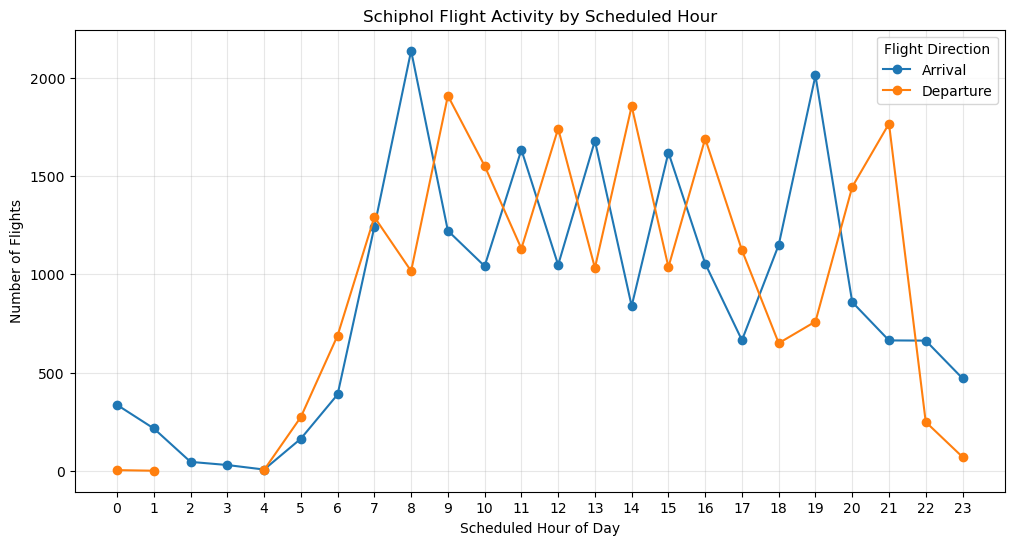

In [151]:
# perform the group-by

hourly_counts = flights.groupby(
    ["scheduled_hour", "flight_direction"]
).size().reset_index(name="flight_count")

hourly_counts.head()

# create the chart visual

hourly_pivot = hourly_counts.pivot(
    index="scheduled_hour",
    columns="flight_direction",
    values="flight_count"
)

plt.figure(figsize=(12, 6))

for column in hourly_pivot.columns:
    plt.plot(
        hourly_pivot.index,
        hourly_pivot[column],
        marker="o",
        label=column
    )

plt.title("Schiphol Flight Activity by Scheduled Hour")
plt.xlabel("Scheduled Hour of Day")
plt.ylabel("Number of Flights")
plt.xticks(range(0, 24))
plt.legend(title="Flight Direction")
plt.grid(True, alpha=0.3)
plt.show()

## (3) I can also zoom out and examine flight activity by time_of_day

This helps show when Schiphol is busiest during a typical operating day, and lends insight into the busiest/most demanding operational periods of the day.

total_flights  unique_airlines  unique_airports
time_of_day flight_direction                                                 
Afternoon   Departure                  8482               68              226
Morning     Arrival                    7667               71              193
            Departure                  7590               62              211
Afternoon   Arrival                    6907               66              210
Evening     Arrival                    5819               59              178
            Departure                  4942               67              144
Overnight   Arrival                     799                9               57
            Departure                   284                5               35

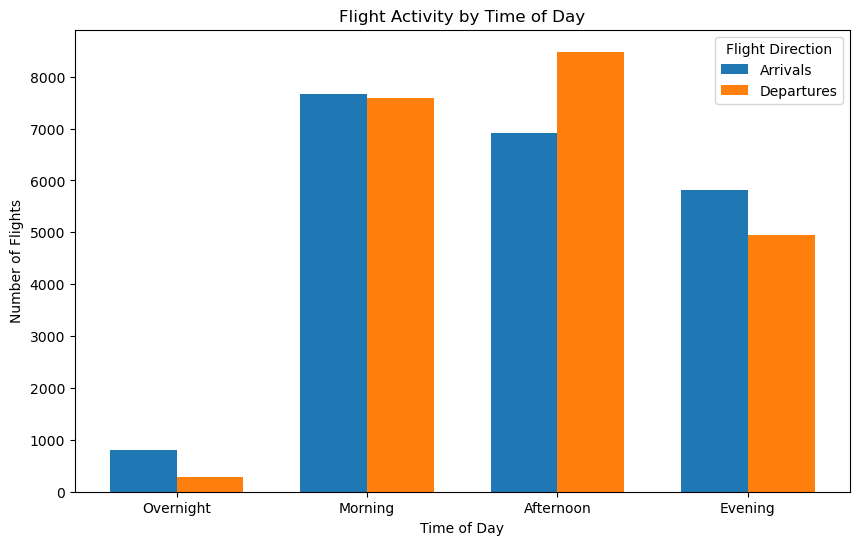

In [152]:
# create the table / group-by

time_activity = flights.groupby(
    ["time_of_day", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_airports=("airport_code", "nunique")
)

time_activity = time_activity.sort_values(
    by="total_flights",
    ascending=False
)

display(time_activity)

# create the chart visual

time_activity_chart = flights.groupby(
    ["time_of_day", "flight_direction"]
).size().reset_index(name="flight_count")

time_activity_pivot = time_activity_chart.pivot(
    index="time_of_day",
    columns="flight_direction",
    values="flight_count"
)

time_order = ["Overnight", "Morning", "Afternoon", "Evening"]
time_activity_pivot = time_activity_pivot.reindex(time_order)

x_positions = np.arange(len(time_activity_pivot.index))
bar_width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x_positions - bar_width / 2,
    time_activity_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    time_activity_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Flight Activity by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Flights")
plt.xticks(
    ticks=x_positions,
    labels=time_activity_pivot.index
)
plt.legend(title="Flight Direction")

plt.show()

## (4) I can also look at flight frequency by day of the week

This can help management better staff the airport, and prepare for busier periods during the week, which could alleviate delays or other operational bottlenecks.

total_flights  unique_airlines  \
scheduled_day flight_direction                                   
Friday        Arrival                    2844               79   
              Departure                  2865               78   
Monday        Arrival                    2874               80   
              Departure                  2867               79   
Saturday      Arrival                    2706               82   
              Departure                  2756               84   
Sunday        Arrival                    2852               76   
              Departure                  2848               77   
Thursday      Arrival                    3586               79   
              Departure                  3617               78   
Tuesday       Arrival                    2791               81   
              Departure                  2826               80   
Wednesday     Arrival                    3539               79   
              Departure                  3519               80   

                                unique_airports  
scheduled_day flight_direction                   
Friday        Arrival                       223  
              Departure                     222  
Monday        Arrival                       224  
              Departure                     224  
Saturday      Arrival                       227  
              Departure                     226  
Sunday        Arrival                       230  
              Departure                     229  
Thursday      Arrival                       231  
              Departure                     230  
Tuesday       Arrival                       224  
              Departure                     222  
Wednesday     Arrival                       221  
              Departure                     216

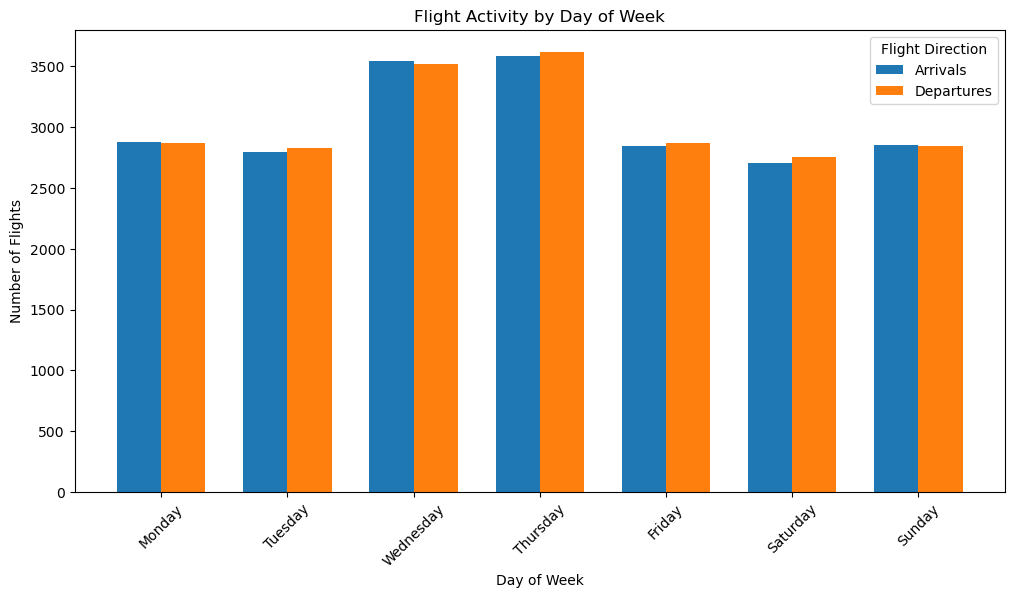

In [153]:
# create the table / group-by

day_activity = flights.groupby(
    ["scheduled_day", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_airports=("airport_code", "nunique")
)

display(day_activity)

# create the chart visual / another group-by

day_activity_chart = flights.groupby(
    ["scheduled_day", "flight_direction"]
).size().reset_index(name="flight_count")

day_activity_pivot = day_activity_chart.pivot(
    index="scheduled_day",
    columns="flight_direction",
    values="flight_count"
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_activity_pivot = day_activity_pivot.reindex(day_order)

x_positions = np.arange(len(day_activity_pivot.index))
bar_width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x_positions - bar_width / 2,
    day_activity_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    day_activity_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Flight Activity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")
plt.xticks(
    ticks=x_positions,
    labels=day_activity_pivot.index,
    rotation=45
)
plt.legend(title="Flight Direction")

plt.show()

Wednesday and Thursday are very clearly the busiest days of the week at Schiphol, and by a decent margin. The other days of the week, surprisingly, are all very similar in form.

## (5) Building off of this, I can then analyze flight volume by scheduled_day and scheduled_hour

This combines some of the previous analyses into a more visually compelling heatmap.

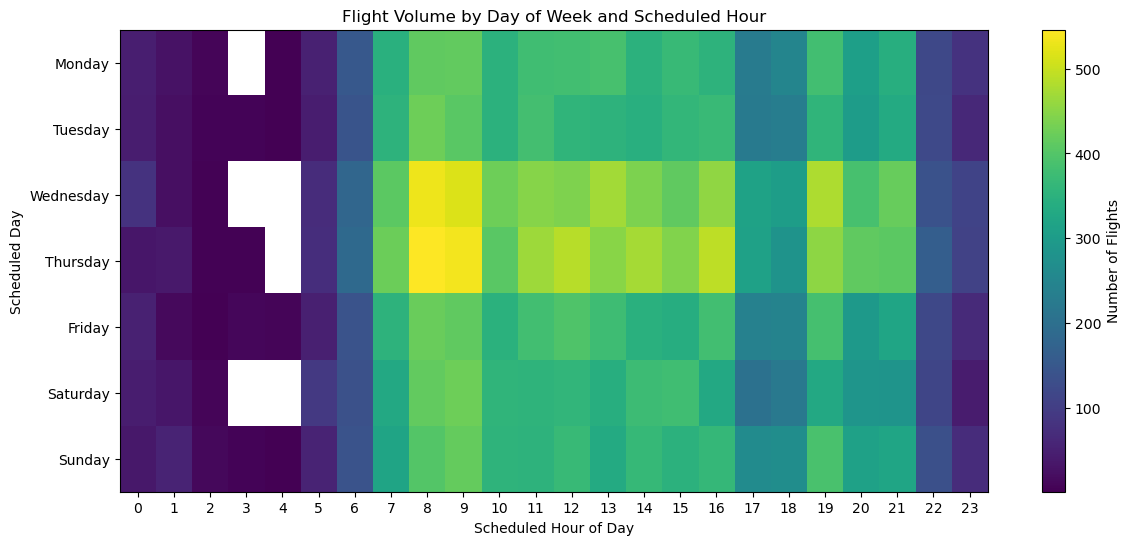

In [154]:
# perform the group-by

day_hour_counts = flights.groupby(
    ["scheduled_day", "scheduled_hour"]
).size().reset_index(name="flight_count")

# arrange

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# create the table

day_hour_pivot = day_hour_counts.pivot(
    index="scheduled_day",
    columns="scheduled_hour",
    values="flight_count"
)

day_hour_pivot = day_hour_pivot.reindex(day_order)

day_hour_pivot

# transform into chart visual

plt.figure(figsize=(14, 6))

plt.imshow(day_hour_pivot, aspect="auto")

plt.title("Flight Volume by Day of Week and Scheduled Hour")
plt.xlabel("Scheduled Hour of Day")
plt.ylabel("Scheduled Day")

plt.xticks(
    ticks=range(len(day_hour_pivot.columns)),
    labels=day_hour_pivot.columns
)

plt.yticks(
    ticks=range(len(day_hour_pivot.index)),
    labels=day_hour_pivot.index
)

plt.colorbar(label="Number of Flights")

plt.show()

## (6) Next, I can examine operations by airline

,total_flights,arrival_count,departure_count,unique_route_airports,average_codeshares,average_delay_minutes,delayed_15_percent
airline_name,,,,,,,
KLM Royal Dutch Airlines,22293,11146,11147,161,4.07,4.44,20.89
Transavia Holland,3265,1648,1617,74,0.86,15.06,38.97
easyJet Europe,1967,918,1049,42,0.00,0.76,16.35
Delta Air Lines,1824,911,913,10,1.58,6.18,23.85
easyJet,972,484,488,10,0.00,8.13,28.89
Arkefly,830,416,414,49,0.00,11.66,27.68
Vueling Airlines,741,370,371,4,1.90,-0.49,18.62
British Airways,695,346,349,2,0.00,1.7,16.2
Scandinavian Airlines System,538,269,269,5,0.00,-3.52,10.45


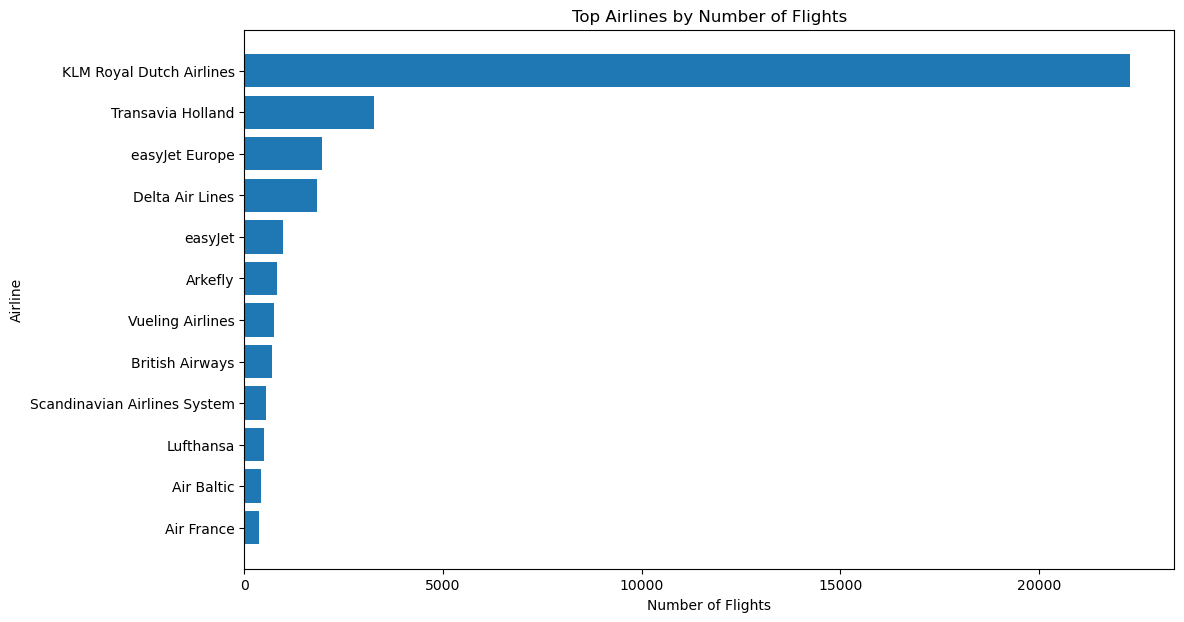

In [155]:
# create the table / group-by

airline_summary = flights.groupby("airline_name").agg(
    total_flights=("flight_number", "count"),
    arrival_count=("flight_direction", lambda x: (x == "Arrival").sum()),
    departure_count=("flight_direction", lambda x: (x == "Departure").sum()),
    unique_route_airports=("airport_code", "nunique"),
    average_codeshares=("codeshare_frequency", "mean"),
    average_delay_minutes=("delay_minutes", "mean"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

airline_summary = airline_summary.sort_values(
    by="total_flights",
    ascending=False
)

airline_summary = airline_summary.round(2)

display(airline_summary.head(15))

# create an accompanying chart visual

top_airlines = airline_summary.head(12)

plt.figure(figsize=(12, 7))

plt.barh(
    top_airlines.index,
    top_airlines["total_flights"]
)

plt.title("Top Airlines by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

plt.gca().invert_yaxis()

plt.show()

## (7) I can combine some of the previous analyses to look at how different airlines spread out their operations at Schiphol.

For airlines that place a greater strain on Schiphol's resources, like KLM, this analysis can help management restrict airlines from adding flights during certain periods. It can also help the airlines themselves better understand their own bottlenecks and how to improve staffing/resources allocation.

total_flights  arrivals  departures
airline_name                 time_of_day                                     
KLM Royal Dutch Airlines     Morning               8281      4428        3853
                             Afternoon             8199      3536        4663
                             Evening               5753      3122        2631
Transavia Holland            Afternoon             1278       613         665
Delta Air Lines              Morning               1101       610         491
Transavia Holland            Overnight              745       491         254
easyJet Europe               Morning                719       180         539
                             Evening                714       457         257
Transavia Holland            Morning                671       137         534
Delta Air Lines              Afternoon              663       241         422
Transavia Holland            Evening                571       407         164
easyJet Europe               Afternoon              534       281         253
easyJet                      Afternoon              336       167         169
                             Evening                329       157         172
Arkefly                      Afternoon              325       153         172
easyJet                      Morning                307       160         147
Arkefly                      Morning                282        67         215
Vueling Airlines             Evening                275       137         138
British Airways              Afternoon              263       144         119
Vueling Airlines             Morning                239       104         135
British Airways              Morning                233        93         140
Vueling Airlines             Afternoon              227       129          98
Scandinavian Airlines System Evening                220       121          99
Lufthansa                    Morning                218        79         139
British Airways              Evening                199       109          90
Scandinavian Airlines System Morning                191        88         103
Lufthansa                    Afternoon              189       107          82
Air Baltic                   Morning                188        94          94
                             Afternoon              180        90          90
Air France                   Afternoon              147        87          60
Scandinavian Airlines System Afternoon              127        60          67
Air France                   Morning                125        61          64
Arkefly                      Evening                112       106           6
                             Overnight              111        90          21
Lufthansa                    Evening                 95        65          30
Air France                   Evening                 86        30          56
Air Baltic                   Evening                 60        30          30
KLM Royal Dutch Airlines     Overnight               60        60           0
Delta Air Lines              Overnight               60        60           0

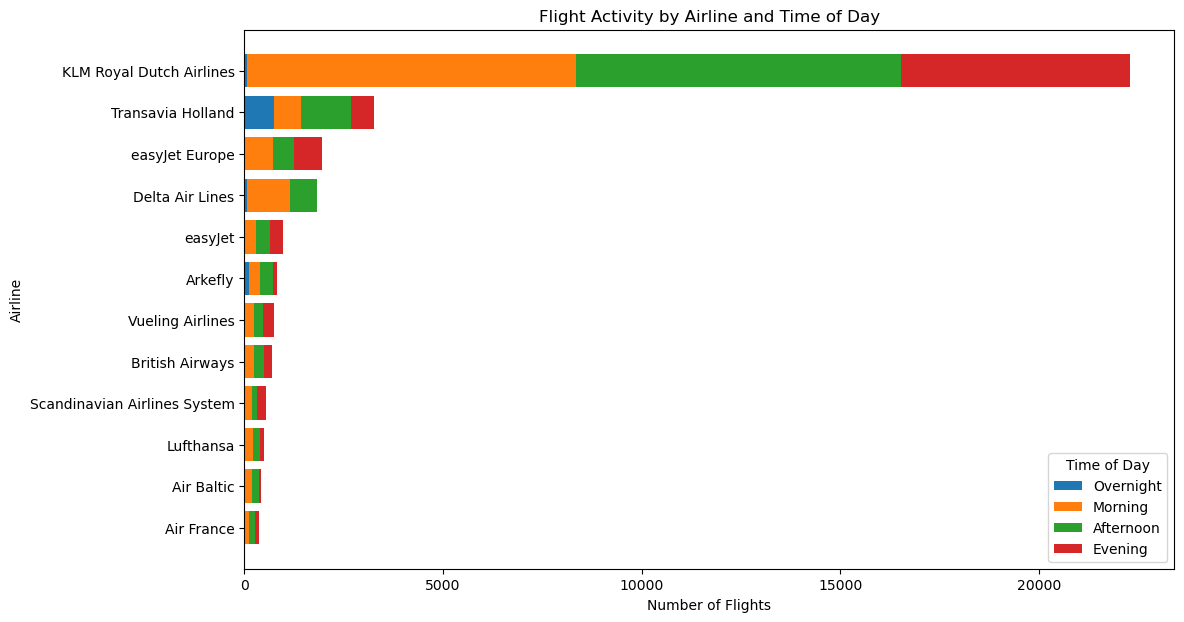

In [156]:
# create the table

top_airline_names = top_airlines.index

airline_time_activity = flights[
    flights["airline_name"].isin(top_airline_names)
].groupby(
    ["airline_name", "time_of_day"]
).agg(
    total_flights=("flight_number", "count"),
    arrivals=("flight_direction", lambda x: (x == "Arrival").sum()),
    departures=("flight_direction", lambda x: (x == "Departure").sum())
)

airline_time_activity = airline_time_activity.sort_values(
    by="total_flights",
    ascending=False
)

display(airline_time_activity)

# create the chart visual

airline_time_chart = flights[
    flights["airline_name"].isin(top_airline_names)
].groupby(
    ["airline_name", "time_of_day"]
).size().reset_index(name="flight_count")

airline_time_pivot = airline_time_chart.pivot(
    index="airline_name",
    columns="time_of_day",
    values="flight_count"
)

airline_time_pivot = airline_time_pivot[time_order]
airline_time_pivot = airline_time_pivot.loc[top_airline_names]
airline_time_pivot = airline_time_pivot.fillna(0)

plt.figure(figsize=(12, 7))

bottom_values = np.zeros(len(airline_time_pivot))

for column in airline_time_pivot.columns:
    plt.barh(
        airline_time_pivot.index,
        airline_time_pivot[column],
        left=bottom_values,
        label=column
    )
    bottom_values = bottom_values + airline_time_pivot[column]

plt.title("Flight Activity by Airline and Time of Day")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")
plt.legend(title="Time of Day")
plt.gca().invert_yaxis()

plt.show()

## (8) Taking a more geographical approach, I can look into which cities are best served from Schiphol

This could inform airport and airline management where to allocate additional capacity, or from where to seek out new/additional service.

,,,total_flights,unique_airlines,arrivals,departures,average_delay_minutes
airport_code,route_airport_name,route_country_name,,,,,
LHR,London Heathrow Airport,United Kingdom,909,4,448,461,2.84
BCN,Josep Tarradellas Barcelona-El Prat Airport,Spain,820,3,411,409,9.1
CPH,Copenhagen Kastrup Airport,Denmark,759,6,374,385,0.12
DUB,Dublin Airport,Ireland,748,5,374,374,4.39
CDG,Charles de Gaulle International Airport,France,746,4,371,375,3.06
MAD,Adolfo Suárez Madrid–Barajas Airport,Spain,681,9,341,340,4.59
LCY,London City Airport,United Kingdom,637,2,317,320,-0.2
ZRH,Zürich Airport,Switzerland,634,2,317,317,7.8
MAN,Manchester Airport,United Kingdom,629,4,315,314,8.64


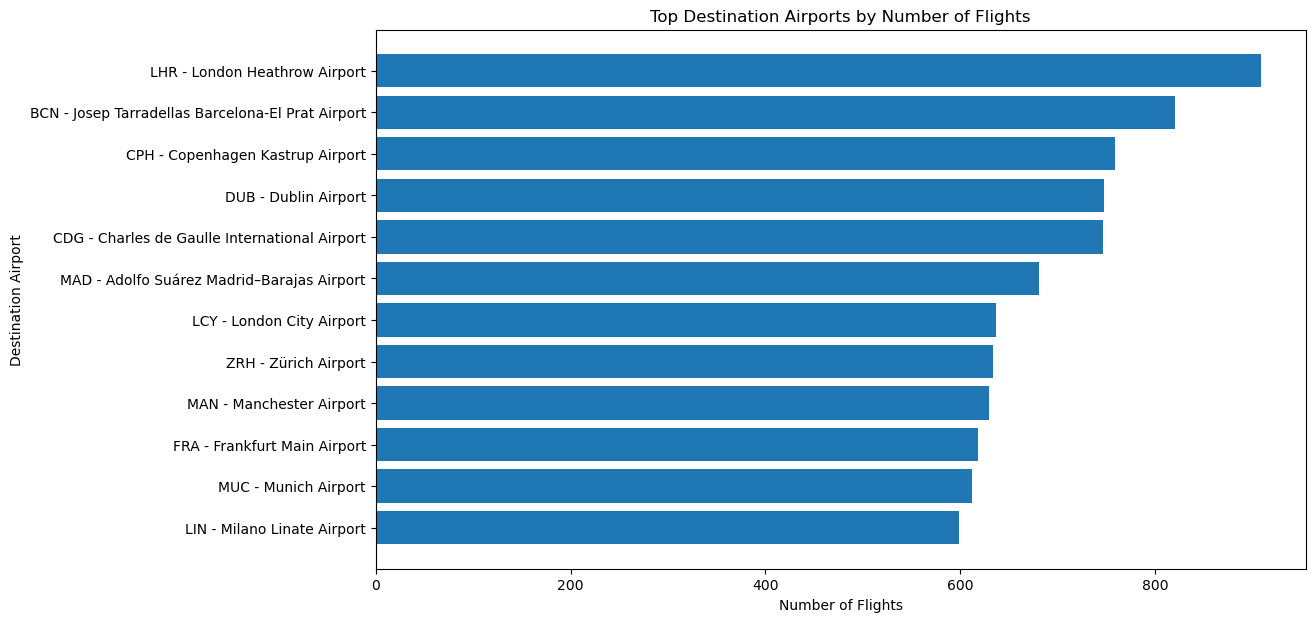

In [157]:
# create the table / group-by

top_destinations = flights.groupby(
    ["airport_code", "route_airport_name", "route_country_name"]
).agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    arrivals=("flight_direction", lambda x: (x == "Arrival").sum()),
    departures=("flight_direction", lambda x: (x == "Departure").sum()),
    average_delay_minutes=("delay_minutes", "mean")
)

top_destinations = top_destinations.sort_values(
    by="total_flights",
    ascending=False
)

top_destinations = top_destinations.round(2)

display(top_destinations.head(20))

# create the chart visual

top_destinations_chart = top_destinations.head(12)

destination_labels = []

for destination in top_destinations_chart.index:
    airport_code = str(destination[0])
    airport_name = str(destination[1])
    destination_labels.append(airport_code + " - " + airport_name)

plt.figure(figsize=(12, 7))

plt.barh(
    destination_labels,
    top_destinations_chart["total_flights"]
)

plt.title("Top Destination Airports by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Destination Airport")
plt.gca().invert_yaxis()

plt.show()


## (9) After, I can look into which countries are best connected from Schiphol Airport (and Amsterdam)

,total_flights,unique_airlines,unique_route_airports,average_delay_minutes,delayed_15_percent
route_country_name,,,,,
United Kingdom,6221,13,25,2.96,18.5
Spain,4081,14,19,8.5,28.61
Germany,3270,14,12,5.65,22.67
United States,3253,15,22,4.9,22.24
Italy,2842,9,21,6.48,23.41
France,2262,8,12,4.48,20.78
Norway,1483,6,6,2.43,15.63
Greece,1391,8,17,11.41,32.45
Denmark,1322,8,4,0.15,15.02


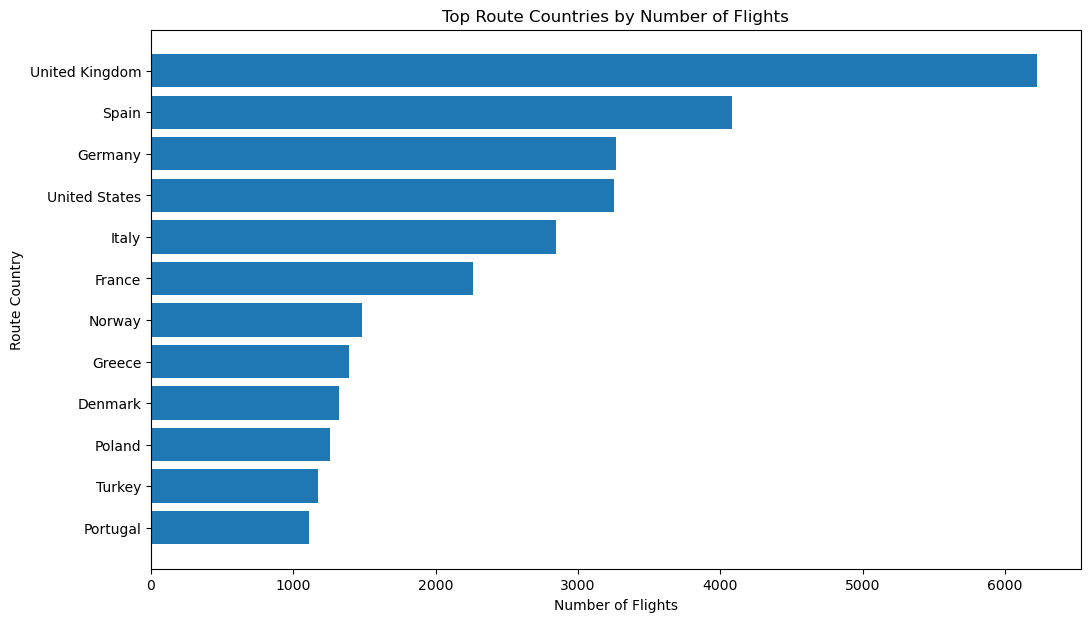

In [158]:
# create the table / group-by

country_summary = flights.groupby("route_country_name").agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_route_airports=("airport_code", "nunique"),
    average_delay_minutes=("delay_minutes", "mean"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

country_summary = country_summary.sort_values(
    by="total_flights",
    ascending=False
)

country_summary = country_summary.round(2)

display(country_summary.head(15))

# create the chart

top_countries = country_summary.head(12)

plt.figure(figsize=(12, 7))

plt.barh(
    top_countries.index,
    top_countries["total_flights"]
)

plt.title("Top Route Countries by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Route Country")

plt.gca().invert_yaxis()

plt.show()

Adding a comment because most of the above is not all surprising - Amsterdam is in Europe and is also a big business hub, so it figures that most of the flights to/from the airport are to other countries on the continent. What's more surprising is that the US is not only the only long-haul destination on this list, but also within the top 5! While this can be mostly explained by a few factors, such as (1) the joint venture partnership between Delta Airlines and KLM, (2) Schiphol's secondary function as a connecting hub, and (3) the relative seasonality of demand between North America and Europe (I am pulling for May), I was still surprised to see that many flights! I was also somewhat surprised to see just how dominant the UK was as well. 

## (10) Continuing with geographical analysis, I can also create a table to show the frequency of flights to each inhabited continent (except Australia)

In [159]:
# create the table / group-by

continent_summary = flights.groupby(
    ["route_continent_name", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_route_airports=("airport_code", "nunique"),
    average_delay_minutes=("delay_minutes", "mean"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

continent_summary = continent_summary.sort_values(
    by="total_flights",
    ascending=False
)

continent_summary = continent_summary.round(2)

continent_summary

total_flights  unique_airlines  \
route_continent_name flight_direction                                   
Europe               Departure                 16156               55   
                     Arrival                   15974               52   
North America        Arrival                    2187               21   
                     Departure                  2154               15   
Asia                 Departure                  2008               40   
                     Arrival                    1952               42   
Africa               Arrival                     769               15   
                     Departure                   739               11   
South America        Arrival                     310                8   
                     Departure                   241                3   

                                       unique_route_airports  \
route_continent_name flight_direction                          
Europe               Departure                           157   
                     Arrival                             161   
North America        Arrival                              39   
                     Departure                            38   
Asia                 Departure                            53   
                     Arrival                              55   
Africa               Arrival                              26   
                     Departure                            25   
South America        Arrival                               8   
                     Departure                             7   

                                       average_delay_minutes  \
route_continent_name flight_direction                          
Europe               Departure                          13.1   
                     Arrival                           -3.16   
North America        Arrival                           -8.56   
                     Departure                         17.91   
Asia                 Departure                         21.34   
                     Arrival                           -2.93   
Africa               Arrival                            1.12   
                     Departure                          21.1   
South America        Arrival                          -16.31   
                     Departure                         16.43   

                                       delayed_15_percent  
route_continent_name flight_direction                      
Europe               Departure                      30.85  
                     Arrival                        12.39  
North America        Arrival                        12.57  
                     Departure                      32.88  
Asia                 Departure                      39.36  
                     Arrival                        17.83  
Africa               Arrival                        17.08  
                     Departure                      43.02  
South America        Arrival                        10.33  
                     Departure                      40.59

## (11) Shifting gears to focus more on operational effects, I can examine delays by time of day

total_flights  average_delay_minutes  \
time_of_day flight_direction                                         
Afternoon   Arrival                    6907                   -1.9   
            Departure                  8482                  17.34   
Evening     Arrival                    5819                  -1.73   
            Departure                  4942                  13.67   
Morning     Arrival                    7667                  -7.56   
            Departure                  7590                  12.25   
Overnight   Arrival                     799                   4.09   
            Departure                   284                   9.67   

                              median_delay_minutes  delayed_15_percent  
time_of_day flight_direction                                            
Afternoon   Arrival                           -7.0               14.22  
            Departure                         11.0               39.45  
Evening     Arrival                           -7.0               16.76  
            Departure                          7.0               32.63  
Morning     Arrival                          -12.0                7.55  
            Departure                          6.0               24.51  
Overnight   Arrival                           -4.0               26.92  
            Departure                          6.0                21.0

flight_direction,Arrival,Departure
time_of_day,,
Overnight,4.09,9.67
Morning,-7.56,12.25
Afternoon,-1.9,17.34
Evening,-1.73,13.67


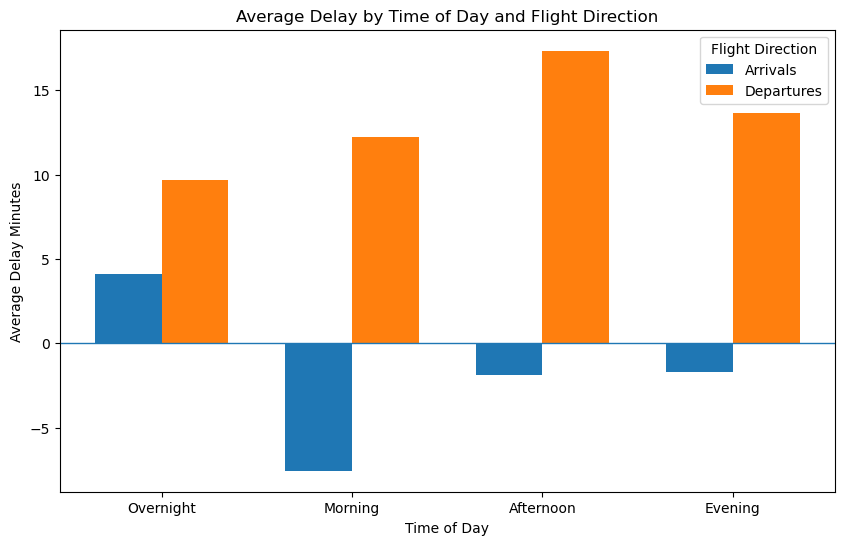

In [160]:
# create the table / group-by

delay_by_time = flights.groupby(
    ["time_of_day", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    average_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

delay_by_time = delay_by_time.round(2)

display(delay_by_time)

# create the pivot table for the visualization

delay_time_pivot = delay_by_time.reset_index().pivot(
    index="time_of_day",
    columns="flight_direction",
    values="average_delay_minutes"
)

time_order = [
    "Overnight",
    "Morning",
    "Afternoon",
    "Evening"
]

delay_time_pivot = delay_time_pivot.reindex(time_order)

display(delay_time_pivot)

# create the chart

x_positions = np.arange(len(delay_time_pivot.index))
bar_width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x_positions - bar_width / 2,
    delay_time_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    delay_time_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Average Delay by Time of Day and Flight Direction")
plt.xlabel("Time of Day")
plt.ylabel("Average Delay Minutes")

plt.xticks(
    ticks=x_positions,
    labels=delay_time_pivot.index
)

plt.axhline(0, linewidth=1)
plt.legend(title="Flight Direction")

plt.show()

flight_direction,Arrival,Departure
time_of_day,,
Overnight,26.92,21.0
Morning,7.55,24.51
Afternoon,14.22,39.45
Evening,16.76,32.63


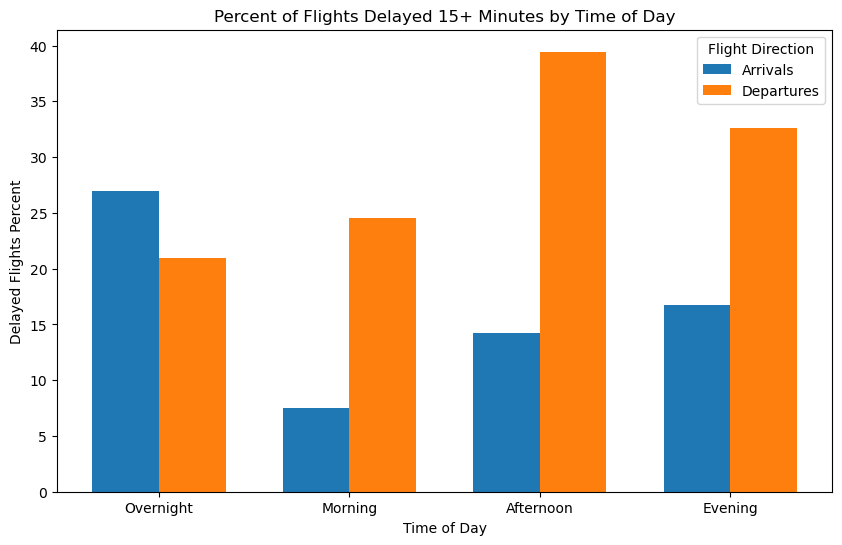

In [161]:
# I can also display the above information in percentage form for a more macro look; create the pivot table

delay_percent_pivot = delay_by_time.reset_index().pivot(
    index="time_of_day",
    columns="flight_direction",
    values="delayed_15_percent"
)

delay_percent_pivot = delay_percent_pivot.reindex(time_order)

display(delay_percent_pivot)

# create the chart

x_positions = np.arange(len(delay_percent_pivot.index))
bar_width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x_positions - bar_width / 2,
    delay_percent_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    delay_percent_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Percent of Flights Delayed 15+ Minutes by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Delayed Flights Percent")

plt.xticks(
    ticks=x_positions,
    labels=delay_percent_pivot.index
)

plt.legend(title="Flight Direction")

plt.show()


## (12) Next, I can look at delay patterns by airline

total_flights  \
airline_name                 flight_direction                  
Air Baltic                   Arrival                     214   
                             Departure                   214   
Air France                   Arrival                     178   
                             Departure                   180   
Arkefly                      Arrival                     416   
                             Departure                   414   
British Airways              Arrival                     346   
                             Departure                   349   
Delta Air Lines              Arrival                     911   
                             Departure                   913   
KLM Royal Dutch Airlines     Arrival                   11146   
                             Departure                 11147   
Lufthansa                    Arrival                     251   
                             Departure                   251   
Scandinavian Airlines System Arrival                     269   
                             Departure                   269   
Transavia Holland            Arrival                    1648   
                             Departure                  1617   
Vueling Airlines             Arrival                     370   
                             Departure                   371   
easyJet                      Arrival                     484   
                             Departure                   488   
easyJet Europe               Arrival                     918   
                             Departure                  1049   

                                               average_delay_minutes  \
airline_name                 flight_direction                          
Air Baltic                   Arrival                           -5.71   
                             Departure                          7.89   
Air France                   Arrival                          -10.08   
                             Departure                         11.46   
Arkefly                      Arrival                             5.6   
                             Departure                         17.74   
British Airways              Arrival                            -5.4   
                             Departure                          8.79   
Delta Air Lines              Arrival                           -9.19   
                             Departure                         21.56   
KLM Royal Dutch Airlines     Arrival                           -4.08   
                             Departure                         12.94   
Lufthansa                    Arrival                           -4.79   
                             Departure                          8.63   
Scandinavian Airlines System Arrival                          -11.31   
                             Departure                          4.28   
Transavia Holland            Arrival                            6.94   
                             Departure                         23.21   
Vueling Airlines             Arrival                          -13.44   
                             Departure                         12.42   
easyJet                      Arrival                           -2.81   
                             Departure                         19.07   
easyJet Europe               Arrival                            -7.5   
                             Departure                          9.02   

                                               median_delay_minutes  \
airline_name                 flight_direction                         
Air Baltic                   Arrival                           -8.0   
                             Departure                          5.5   
Air France                   Arrival                          -17.0   
                             Departure                          5.0   
Arkefly                      Arrival                           -1.0   
            

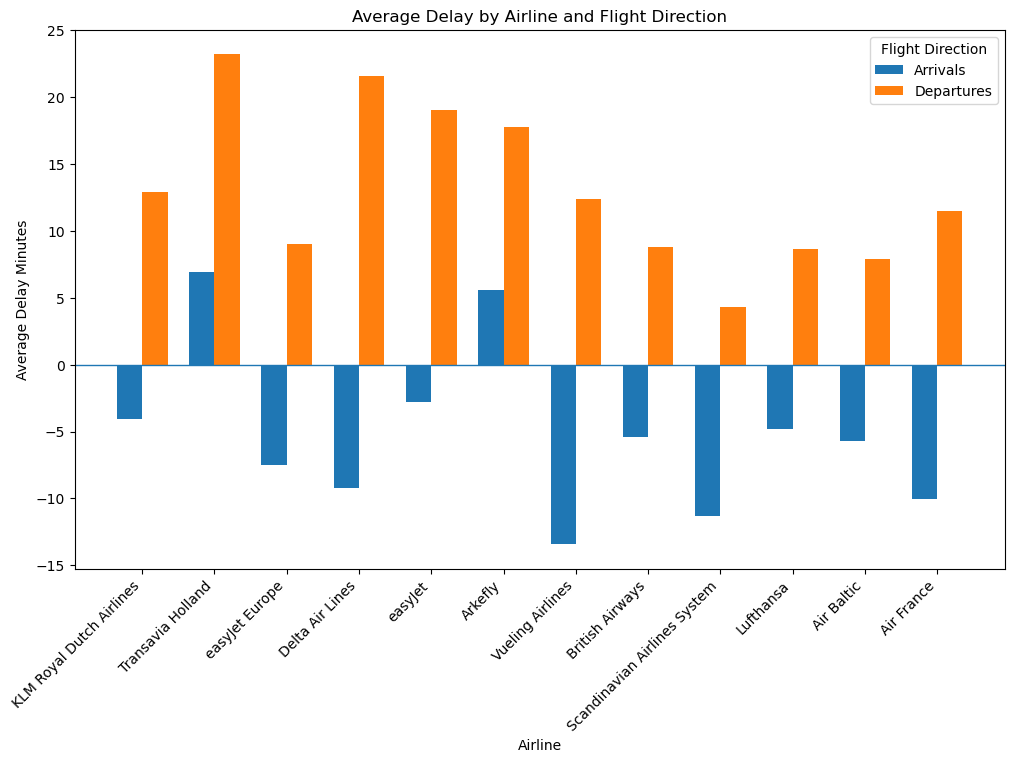

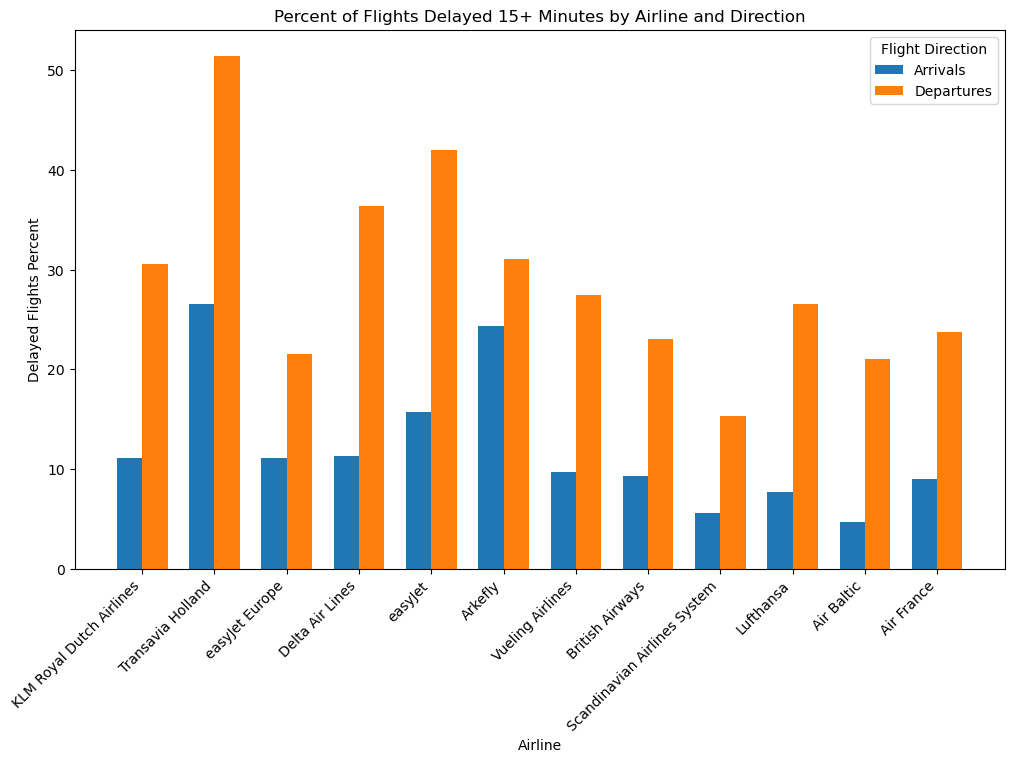

In [162]:
# create the table

airline_delay = flights[
    flights["airline_name"].isin(top_airline_names)
].groupby(
    ["airline_name", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    average_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

airline_delay = airline_delay.round(2)

display(airline_delay)

# create the chart visual

airline_delay_chart = airline_delay.reset_index()

airline_delay_pivot = airline_delay_chart.pivot(
    index="airline_name",
    columns="flight_direction",
    values="average_delay_minutes"
)

airline_delay_pivot = airline_delay_pivot.loc[top_airline_names]

x_positions = np.arange(len(airline_delay_pivot.index))
bar_width = 0.35

plt.figure(figsize=(12, 7))

plt.bar(
    x_positions - bar_width / 2,
    airline_delay_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    airline_delay_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Average Delay by Airline and Flight Direction")
plt.xlabel("Airline")
plt.ylabel("Average Delay Minutes")
plt.xticks(
    ticks=x_positions,
    labels=airline_delay_pivot.index,
    rotation=45,
    ha="right"
)
plt.axhline(0, linewidth=1)
plt.legend(title="Flight Direction")

plt.show()

# chart in percentage terms - including this because it's easier to comprehend than the above

airline_delay_percent_pivot = airline_delay_chart.pivot(
    index="airline_name",
    columns="flight_direction",
    values="delayed_15_percent"
)

airline_delay_percent_pivot = airline_delay_percent_pivot.loc[top_airline_names]

x_positions = np.arange(len(airline_delay_percent_pivot.index))
bar_width = 0.35

plt.figure(figsize=(12, 7))

plt.bar(
    x_positions - bar_width / 2,
    airline_delay_percent_pivot["Arrival"],
    width=bar_width,
    label="Arrivals"
)

plt.bar(
    x_positions + bar_width / 2,
    airline_delay_percent_pivot["Departure"],
    width=bar_width,
    label="Departures"
)

plt.title("Percent of Flights Delayed 15+ Minutes by Airline and Direction")
plt.xlabel("Airline")
plt.ylabel("Delayed Flights Percent")
plt.xticks(
    ticks=x_positions,
    labels=airline_delay_percent_pivot.index,
    rotation=45,
    ha="right"
)
plt.legend(title="Flight Direction")

plt.show()

## (13) I can make the above analysis more granular by adding a time of day component

Index(['KLM Royal Dutch Airlines', 'Transavia Holland', 'easyJet Europe',
       'Delta Air Lines', 'easyJet'],
      dtype='str', name='airline_name')

total_flights  \
airline_name             time_of_day flight_direction                  
Delta Air Lines          Afternoon   Arrival                     241   
                                     Departure                   422   
                         Morning     Arrival                     610   
                                     Departure                   491   
                         Overnight   Arrival                      60   
KLM Royal Dutch Airlines Afternoon   Arrival                    3536   
                                     Departure                  4663   
                         Evening     Arrival                    3122   
                                     Departure                  2631   
                         Morning     Arrival                    4428   
                                     Departure                  3853   
                         Overnight   Arrival                      60   
Transavia Holland        Afternoon   Arrival                     613   
                                     Departure                   665   
                         Evening     Arrival                     407   
                                     Departure                   164   
                         Morning     Arrival                     137   
                                     Departure                   534   
                         Overnight   Arrival                     491   
                                     Departure                   254   
easyJet                  Afternoon   Arrival                     167   
                                     Departure                   169   
                         Evening     Arrival                     157   
                                     Departure                   172   
                         Morning     Arrival                     160   
                                     Departure                   147   
easyJet Europe           Afternoon   Arrival                     281   
                                     Departure                   253   
                         Evening     Arrival                     457   
                                     Departure                   257   
                         Morning     Arrival                     180   
                                     Departure                   539   

                                                       average_delay_minutes  \
airline_name             time_of_day flight_direction                          
Delta Air Lines          Afternoon   Arrival                           -8.29   
                                     Departure                         16.67   
                         Morning     Arrival                           -8.13   
                                     Departure                         25.36   
                         Overnight   Arrival                          -24.47   
KLM Royal Dutch Airlines Afternoon   Arrival                           -1.91   
                                     Departure                         15.28   
                         Evening     Arrival                           -0.61   
                                     Departure                         12.68   
                         Morning     Arrival                           -8.09   
                                     Departure                         10.31   
                         Overnight   Arrival                          -17.31   
Transavia Holland        Afternoon   Arrival                             5.6   
                                     Departure                         27.43   
                         Evening     Arrival                           14.11   
                                     Departure                         37.12   
                         Morning     Arrival                           -5.89   
                                     Departure                         19.75   
      

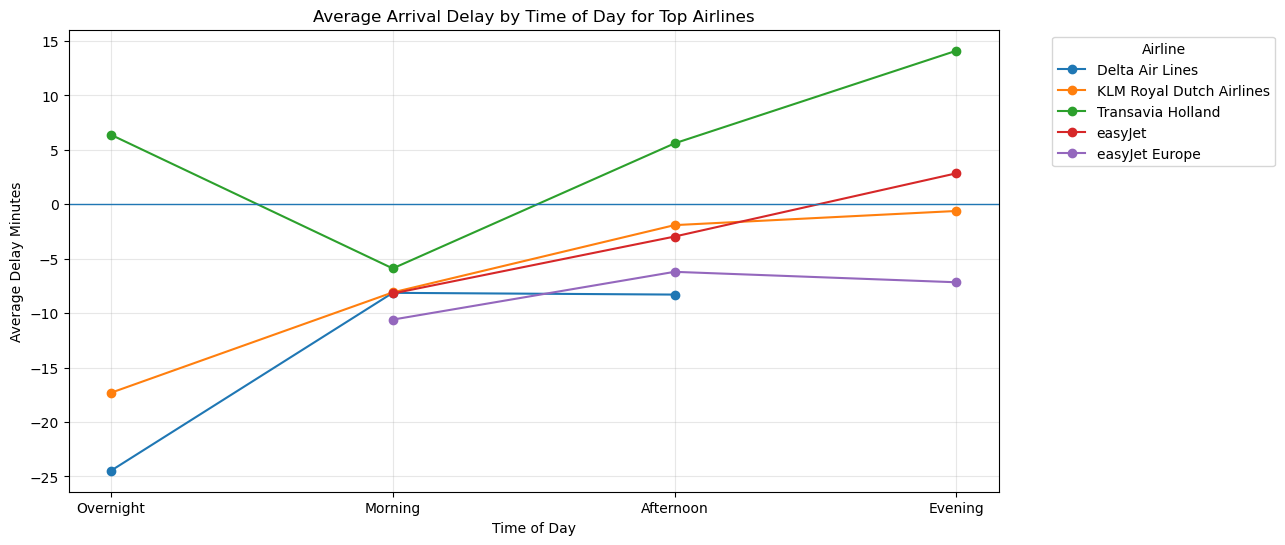

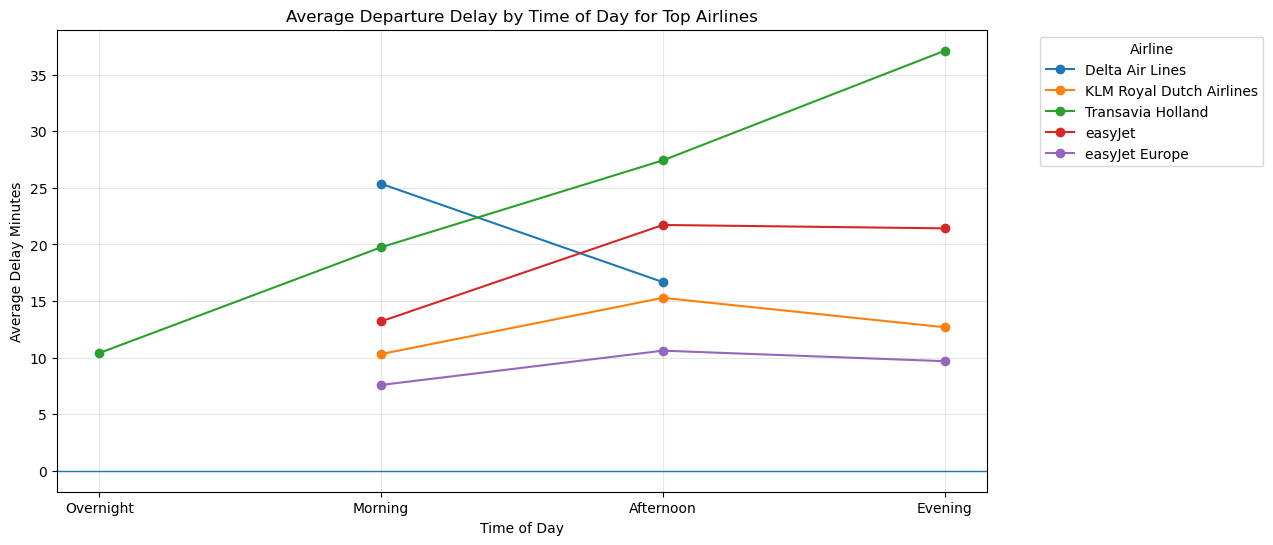

In [163]:
# limit the analysis to the top 5 airlines, for sample size purposes

top_5_airlines = flights["airline_name"].value_counts().head(5).index

display(top_5_airlines)

# create the table / group-by

airline_time_delay = flights[
    flights["airline_name"].isin(top_5_airlines)
].groupby(
    ["airline_name", "time_of_day", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    average_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

airline_time_delay = airline_time_delay.round(2)

display(airline_time_delay)

# create the chart visual for arrivals

arrival_time_delay = airline_time_delay.reset_index()

arrival_time_delay = arrival_time_delay[
    arrival_time_delay["flight_direction"] == "Arrival"
]

arrival_time_delay_pivot = arrival_time_delay.pivot(
    index="time_of_day",
    columns="airline_name",
    values="average_delay_minutes"
)

arrival_time_delay_pivot = arrival_time_delay_pivot.reindex(time_order)

plt.figure(figsize=(12, 6))

for airline in arrival_time_delay_pivot.columns:
    plt.plot(
        arrival_time_delay_pivot.index,
        arrival_time_delay_pivot[airline],
        marker="o",
        label=airline
    )

plt.title("Average Arrival Delay by Time of Day for Top Airlines")
plt.xlabel("Time of Day")
plt.ylabel("Average Delay Minutes")
plt.axhline(0, linewidth=1)
plt.legend(title="Airline", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.show()

# create the chart visual for departures

departure_time_delay = airline_time_delay.reset_index()

departure_time_delay = departure_time_delay[
    departure_time_delay["flight_direction"] == "Departure"
]

departure_time_delay_pivot = departure_time_delay.pivot(
    index="time_of_day",
    columns="airline_name",
    values="average_delay_minutes"
)

departure_time_delay_pivot = departure_time_delay_pivot.reindex(time_order)

plt.figure(figsize=(12, 6))

for airline in departure_time_delay_pivot.columns:
    plt.plot(
        departure_time_delay_pivot.index,
        departure_time_delay_pivot[airline],
        marker="o",
        label=airline
    )

plt.title("Average Departure Delay by Time of Day for Top Airlines")
plt.xlabel("Time of Day")
plt.ylabel("Average Delay Minutes")
plt.axhline(0, linewidth=1)
plt.legend(title="Airline", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.show()



## (14) Doubling down on operational analysis, I can also create a table to look at data related to Schiphol's four terminals

In [164]:
# create the table / group-by

terminal_summary = flights.groupby(
    ["terminal", "flight_direction"]
).agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    unique_gates=("gate", "nunique"),
    average_delay_minutes=("delay_minutes", "mean"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

terminal_summary = terminal_summary.sort_values(
    by="total_flights",
    ascending=False
)

terminal_summary = terminal_summary.round(2)

terminal_summary

total_flights  unique_airlines  unique_gates  \
terminal   flight_direction                                                 
Terminal 1 Departure                 10993               21           105   
Terminal 2 Arrival                    8965                5           101   
           Departure                  4420                8            85   
Terminal 3 Arrival                    4380               65           115   
           Departure                  4217               53           123   
Terminal 1 Arrival                    3770               22            61   
Terminal 4 Arrival                    2440               63           108   
Unknown    Departure                   937               43            34   
           Arrival                     900               48            50   
Cargo      Arrival                     737               23             0   
           Departure                   731               23             0   

                             average_delay_minutes  delayed_15_percent  
terminal   flight_direction                                             
Terminal 1 Departure                         14.26                33.7  
Terminal 2 Arrival                           -4.07                10.5  
           Departure                         12.96               28.43  
Terminal 3 Arrival                           -5.32                13.4  
           Departure                          14.2               31.34  
Terminal 1 Arrival                           -3.14               14.03  
Terminal 4 Arrival                           -4.41               15.33  
Unknown    Departure                         26.89               43.55  
           Arrival                            53.4               42.86  
Cargo      Arrival                            6.42                27.1  
           Departure                         31.37               40.77

## (15) Continuing, I can examine the data by aircraft type

,total_flights,unique_airlines,average_delay_minutes,delayed_15_percent
aircraft_name,,,,
Boeing 737-800 (winglets),6586,19,7.97,27.22
Airbus A321neo,4734,22,10.01,32.52
Embraer 190,4680,5,3.78,17.56
Embraer 175 (long wing),3538,2,1.2,13.42
Embraer E195-E2,3051,4,7.51,23.15
Airbus A320,2460,25,3.65,20.6
Airbus A320neo,2301,19,1.36,17.52
Airbus A319,1497,11,0.48,17.01
Airbus A220-300,1118,8,2.5,16.25


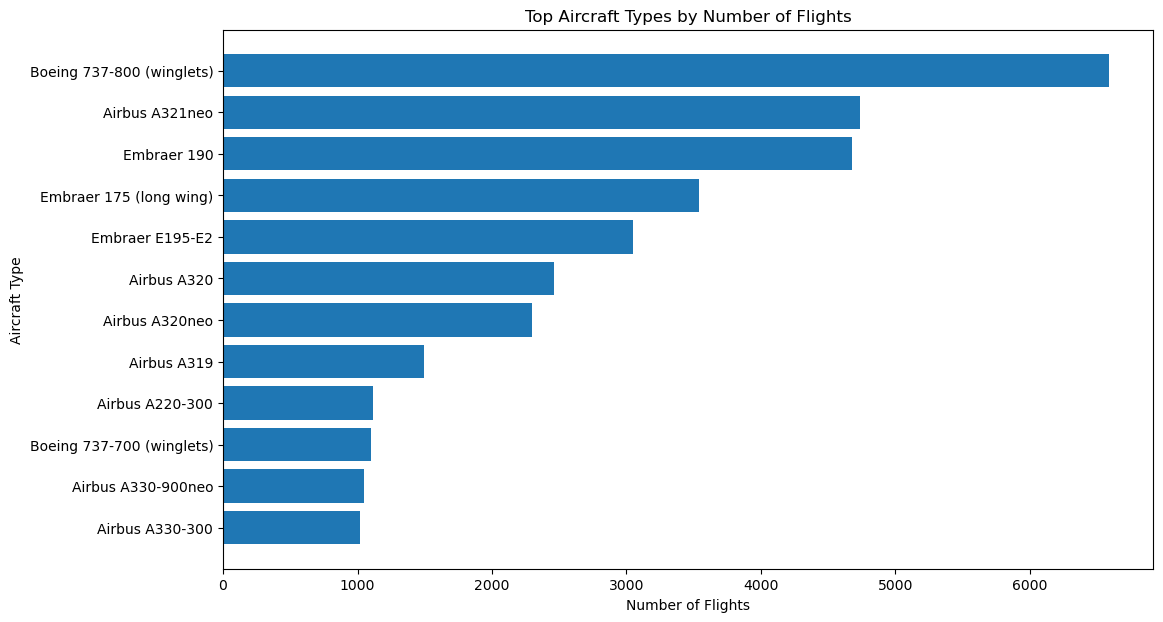

In [165]:
# create the table / group-by

aircraft_summary = flights.groupby("aircraft_name").agg(
    total_flights=("flight_number", "count"),
    unique_airlines=("airline_name", "nunique"),
    average_delay_minutes=("delay_minutes", "mean"),
    delayed_15_percent=("delay_minutes", lambda x: (x >= 15).mean() * 100)
)

aircraft_summary = aircraft_summary.sort_values(
    by="total_flights",
    ascending=False
)

aircraft_summary = aircraft_summary.round(2)

display(aircraft_summary.head(15))

# create the chart visual

top_aircraft = aircraft_summary.head(12)

plt.figure(figsize=(12, 7))

plt.barh(
    top_aircraft.index,
    top_aircraft["total_flights"]
)

plt.title("Top Aircraft Types by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Aircraft Type")

plt.gca().invert_yaxis()

plt.show()


## (16) Finally, I can examine KLM's aircraft usage on arriving and departing flights by time of day

Since they are Schiphol Airport's largest and home carrier, delving more into their operations can help the airport better prepare to handle certain aircraft types, especially at certain periods of the day.

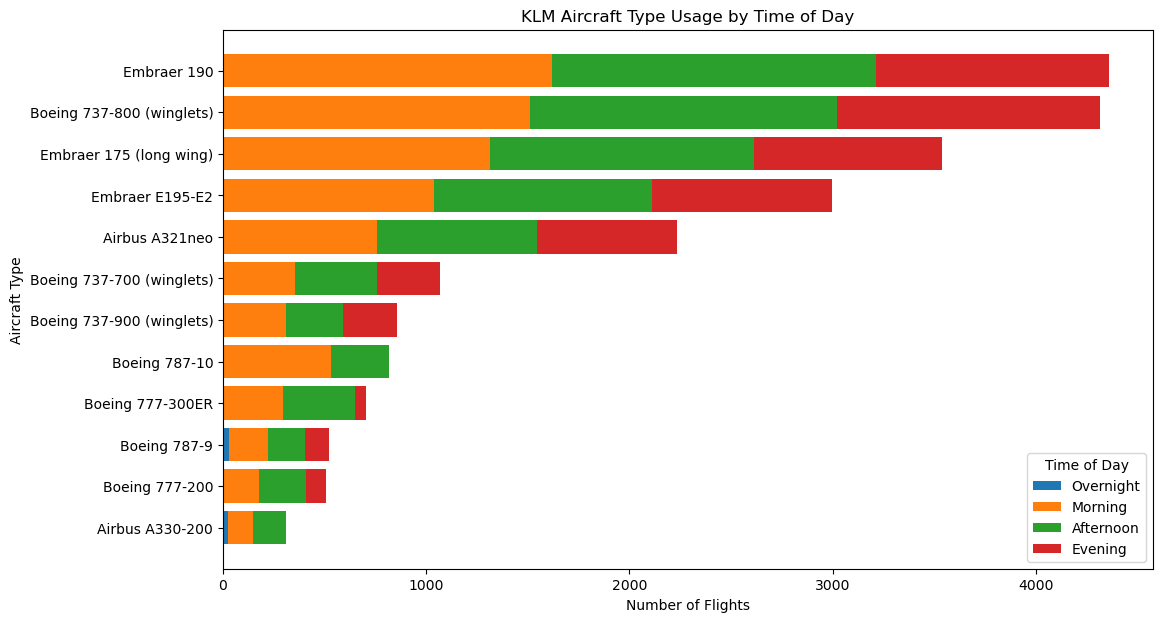

In [166]:
# create the table / group-by

klm_aircraft_time = flights[
    flights["airline_name"].str.contains("KLM", case=False, na=False)
].groupby(
    ["aircraft_name", "time_of_day"]
).agg(
    total_flights=("flight_number", "count"),
    arrivals=("flight_direction", lambda x: (x == "Arrival").sum()),
    departures=("flight_direction", lambda x: (x == "Departure").sum()),
    average_delay_minutes=("delay_minutes", "mean")
)

klm_aircraft_time = klm_aircraft_time.sort_values(
    by="total_flights",
    ascending=False
)

klm_aircraft_time = klm_aircraft_time.round(2)

klm_aircraft_time.head(25)

# create the pivot table; fill in missing combos; reorder time of day columns; keep the top 12 planes for visual clarity

klm_aircraft_time_chart = flights[
    flights["airline_name"].str.contains("KLM", case=False, na=False)
].groupby(
    ["aircraft_name", "time_of_day"]
).size().reset_index(name="flight_count")

klm_aircraft_time_pivot = klm_aircraft_time_chart.pivot(
    index="aircraft_name",
    columns="time_of_day",
    values="flight_count"
)

klm_aircraft_time_pivot = klm_aircraft_time_pivot.fillna(0)

time_order = ["Overnight", "Morning", "Afternoon", "Evening"]
klm_aircraft_time_pivot = klm_aircraft_time_pivot[time_order]

top_klm_aircraft = flights[
    flights["airline_name"].str.contains("KLM", case=False, na=False)
]["aircraft_name"].value_counts().head(12).index

klm_aircraft_time_pivot = klm_aircraft_time_pivot.loc[top_klm_aircraft]

klm_aircraft_time_pivot

# create the chart visual

plt.figure(figsize=(12, 7))

bottom_values = np.zeros(len(klm_aircraft_time_pivot))

for column in klm_aircraft_time_pivot.columns:
    plt.barh(
        klm_aircraft_time_pivot.index,
        klm_aircraft_time_pivot[column],
        left=bottom_values,
        label=column
    )
    bottom_values = bottom_values + klm_aircraft_time_pivot[column]

plt.title("KLM Aircraft Type Usage by Time of Day")
plt.xlabel("Number of Flights")
plt.ylabel("Aircraft Type")
plt.legend(title="Time of Day")
plt.gca().invert_yaxis()


# Step 3 : using models to predict delays

## Constructing a first model (linear)

### (1) First, I'm going to create a new dataframe for modeling purposes, as I may need to further modify data 

In [167]:
model_data = flights.copy()

### (2) Next, I'm going to engineer some dummy variables to include in the model that may help make it more accurate

In [168]:
# feature 1 : whether the flight is operated by KLM

model_data["is_klm"] = model_data["airline_name"].str.contains(
    "KLM",
    case=False,
    na=False
).astype(int)

# feature 2 : whether the flight operates during peak hours (7AM-10AM; 4PM-8PM)

model_data["is_peak_hour"] = model_data["scheduled_hour"].apply(
    lambda hour: 1 if hour in [7, 8, 9, 10, 16, 17, 18, 19, 20] else 0
)

# feature 3 : whether the flight is scheduled on a weekend

model_data["is_weekend"] = model_data["scheduled_day"].apply(
    lambda day: 1 if day in ["Saturday", "Sunday"] else 0
)

### (3) Next, I'm going to create a simplified airline group

As the above EDA showed, the vast majority of flights at AMS are concentrated amongst a small group of airlines. For sample size purposes, I will make dummy variables for the top 10 airlines, and group the remainders under an umbrella 'other' category.

In [169]:
# grouping airlines

top_10_airlines = model_data["airline_name"].value_counts().head(10).index

model_data["airline_group"] = model_data["airline_name"].apply(
    lambda airline: airline if airline in top_10_airlines else "Other"
)

### (4) Then, I will select the columns I'd like to use for the model

In [170]:
# selecting columns, dropping missing data

model_columns = [
    "delay_minutes",
    "flight_direction",
    "scheduled_hour",
    "time_of_day",
    "scheduled_day",
    "airline_group",
    "route_continent_name",
    "terminal",
    "codeshare_frequency",
    "is_klm",
    "is_peak_hour",
    "is_weekend",
]

model_data = model_data[model_columns]

model_data = model_data.dropna()

model_data.head()


,delay_minutes,flight_direction,scheduled_hour,time_of_day,scheduled_day,airline_group,route_continent_name,terminal,codeshare_frequency,is_klm,is_peak_hour,is_weekend
0,20,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 3,0,0,0,0
1,12,Arrival,0,Overnight,Wednesday,Transavia Holland,Africa,Terminal 3,0,0,0,0
2,-26,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 1,0,0,0,0
3,19,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 1,0,0,0,0
4,-11,Arrival,0,Overnight,Wednesday,Transavia Holland,Africa,Terminal 1,1,0,0,0


### (5) Then, I can separate explanatory and target variables

In [171]:
# separation

y = model_data["delay_minutes"]

X = model_data.drop(columns=["delay_minutes"])

# create dummy variables for categorical variables

X = pd.get_dummies(
    X,
    columns=[
        "flight_direction",
        "time_of_day",
        "scheduled_day",
        "airline_group",
        "route_continent_name",
        "terminal",
    ],
    drop_first=True
)

X.head()

,scheduled_hour,codeshare_frequency,is_klm,is_peak_hour,is_weekend,flight_direction_Departure,time_of_day_Evening,time_of_day_Morning,time_of_day_Overnight,scheduled_day_Monday,scheduled_day_Saturday,scheduled_day_Sunday,scheduled_day_Thursday,scheduled_day_Tuesday,scheduled_day_Wednesday,airline_group_British Airways,airline_group_Delta Air Lines,airline_group_KLM Royal Dutch Airlines,airline_group_Lufthansa,airline_group_Other,airline_group_Scandinavian Airlines System,airline_group_Transavia Holland,airline_group_Vueling Airlines,airline_group_easyJet,airline_group_easyJet Europe,route_continent_name_Asia,route_continent_name_Europe,route_continent_name_North America,route_continent_name_South America,terminal_Terminal 1,terminal_Terminal 2,terminal_Terminal 3,terminal_Terminal 4,terminal_Unknown
0,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False
1,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
3,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
4,0,1,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False


### (6) I can now split the data into training and testing sets, and then train the model

In [172]:
# split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# train

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### (7) Finally, we can use the model to make predictions on the test set, and then evaluate these predictions

In [173]:
# predictions

y_pred = linear_model.predict(X_test)

# evaluations

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

linear_model_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Value": [mae, mse, rmse, r2]
})

linear_model_metrics["Value"] = linear_model_metrics["Value"].round(3)

linear_model_metrics

,Metric,Value
0,MAE,15.466
1,MSE,915.894
2,RMSE,30.264
3,R-squared,0.112


My R-squared value is pretty low - I can interpret this as meaning that my model explains about 11.2% of the variation in delay minutes. While this result may, at face value, seem really bad, it's actually not unexpected. Delays are unpredictable! While there is definitely some impact from operational factors, like congestion or airline, it's far more likely that the majority of the flights in the dataset were delayed due to non-operational factors, such as maintenance issues, adverse weather conditions, or inbound aircraft delays. Additionally, there is likely some error in my model due to outlier delay values (I found instances of day-long delays); I elected not to remove these because while very lengthy delays are outliers, they are not irrational values. They happen quite frequently, and are likely not an artifact of poor reporting quality. Finally, the model doesn't account for conditions at the destination (departing flights) or origin (arriving flights); this could also play a massive role in predicting delays.

My model is limited by the data available on the Schihpol Airport API, which is why it doesn't perform spectacularly. There are other explanatory variables that would likely be far more effective at predicting delays that are simply not available to me. In future analyses, finding a way to add a weather element to the model would be something to consider, but not necessarily the point - my intention was to explore how operational factors predict delays, and weather is not an operational factor (in this sense).

Since the R-squared value was so low, I included a baseline test below to ensure that my model was not just guessing delay times.

(for reference, before removing outliers and assigning cargo flights to the cargo terminal, my R-squared was 0.048)

In [174]:
baseline_prediction = y_train.mean()

baseline_predictions = np.repeat(
    baseline_prediction,
    len(y_test)
)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_predictions)

baseline_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Baseline Model": [baseline_mae, baseline_mse, baseline_rmse, baseline_r2],
    "Linear Regression Model": [mae, mse, rmse, r2]
})

baseline_metrics = baseline_metrics.round(3)

baseline_metrics

,Metric,Baseline Model,Linear Regression Model
0,MAE,17.315,15.466
1,MSE,1031.176,915.894
2,RMSE,32.112,30.264
3,R-squared,-0.000,0.112


My model is not just guessing the mean delay time, which is good.

### (8) Adding a couple visual elements to better understand the model and its inputs/components

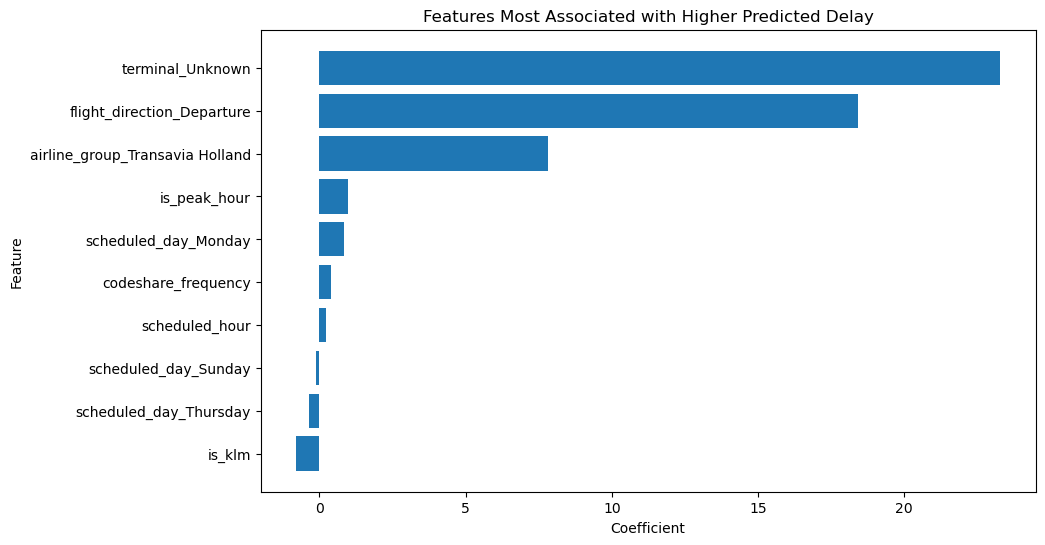

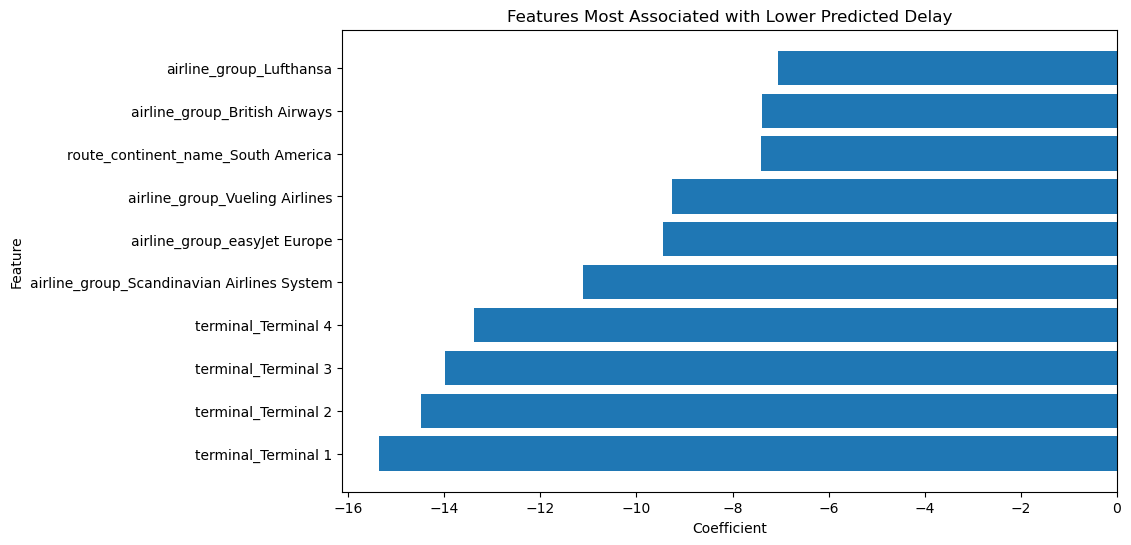

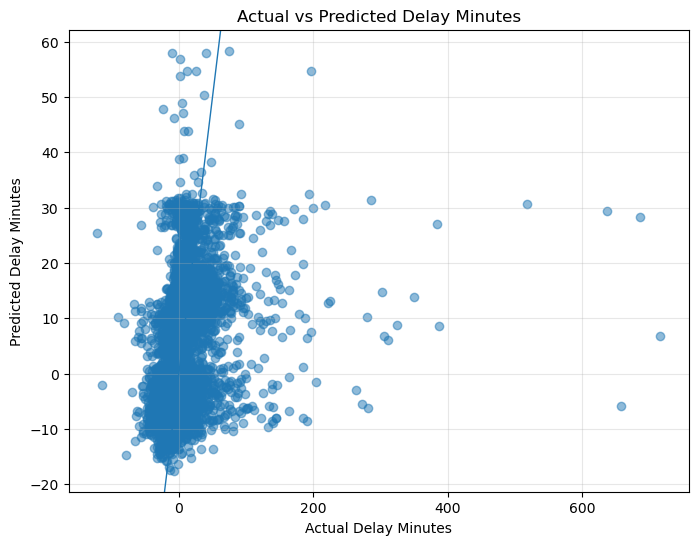

In [175]:
# create a dataframe with the coefficients to analyze their contributions to the model

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="coefficient",
    ascending=False
)

coefficients.head(15)

# display the coefficients most associated with higher delay time

top_positive_coefficients = coefficients.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive_coefficients["feature"],
    top_positive_coefficients["coefficient"]
)

plt.title("Features Most Associated with Higher Predicted Delay")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

# display the coefficients most associated with lower delay time

top_negative_coefficients = coefficients.tail(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_coefficients["feature"],
    top_negative_coefficients["coefficient"]
)

plt.title("Features Most Associated with Lower Predicted Delay")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

# display actual versus predicted delay minutes in the model

actual_vs_predicted = pd.DataFrame({
    "actual_delay_minutes": y_test,
    "predicted_delay_minutes": y_pred
})

actual_vs_predicted.head(10)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_vs_predicted["actual_delay_minutes"],
    actual_vs_predicted["predicted_delay_minutes"],
    alpha=0.5
)

plt.title("Actual vs Predicted Delay Minutes")
plt.xlabel("Actual Delay Minutes")
plt.ylabel("Predicted Delay Minutes")

plt.axline(
    (0, 0),
    slope=1,
    linewidth=1
)

plt.grid(True, alpha=0.3)

plt.show()

The terminal_Unknown feature is kind of a mystery to me. Adding the cargo terminal classification helped reduce the value of the coefficient on this term, but didn't really fix it. I ran some test code to see what kinds of entries had terminal_Unknown values, and they were all (at least what I could see) regularly scheduled passenger flights. Part of the issue here may actually be poor reporting - a lot of these flights were also missing actual_time values (makes sense - actual_time keeps track of when a plane leaves/arrives at the gate, which would be unknown without a terminal value), which means that this specific subset of data is likely causing some problems in the model.

## Constructing a second model (logistic)

### (0) Import more sklearn features

In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### (1) Create a new dataframe for the logistic regression (similar to above) and add features

In [177]:
# create df

logit_model_data = flights.copy()

# create target variable:
# 1 = flight was delayed by 15+ minutes
# 0 = flight was not delayed by 15+ minutes

logit_model_data["is_delayed_15"] = logit_model_data["delay_minutes"].apply(
    lambda delay: 1 if delay >= 15 else 0
)

# feature engineer

logit_model_data["is_klm"] = logit_model_data["airline_name"].str.contains(
    "KLM",
    case=False,
    na=False
).astype(int)

logit_model_data["is_peak_hour"] = logit_model_data["scheduled_hour"].apply(
    lambda hour: 1 if hour in [7, 8, 9, 10, 16, 17, 18, 19, 20] else 0
)

logit_model_data["is_weekend"] = logit_model_data["scheduled_day"].apply(
    lambda day: 1 if day in ["Saturday", "Sunday"] else 0
)

# group airlines

top_10_airlines_logit = logit_model_data["airline_name"].value_counts().head(10).index

logit_model_data["airline_group"] = logit_model_data["airline_name"].apply(
    lambda airline: airline if airline in top_10_airlines_logit else "Other"
)

### (2) Select the relevant columns and clean

In [178]:
# selection

logit_model_columns = [
    "is_delayed_15",
    "flight_direction",
    "scheduled_hour",
    "time_of_day",
    "scheduled_day",
    "airline_group",
    "route_continent_name",
    "terminal",
    "codeshare_frequency",
    "is_klm",
    "is_peak_hour",
    "is_weekend",
]

logit_model_data = logit_model_data[logit_model_columns]

# cleaning

logit_model_data = logit_model_data.dropna()

logit_model_data = logit_model_data[
    logit_model_data["terminal"] != "Unknown"
]

logit_model_data.head()

,is_delayed_15,flight_direction,scheduled_hour,time_of_day,scheduled_day,airline_group,route_continent_name,terminal,codeshare_frequency,is_klm,is_peak_hour,is_weekend
0,1,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 3,0,0,0,0
1,0,Arrival,0,Overnight,Wednesday,Transavia Holland,Africa,Terminal 3,0,0,0,0
2,0,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 1,0,0,0,0
3,1,Arrival,0,Overnight,Wednesday,Transavia Holland,Europe,Terminal 1,0,0,0,0
4,0,Arrival,0,Overnight,Wednesday,Transavia Holland,Africa,Terminal 1,1,0,0,0


### (3) Separate target variable from explanatory variable and create dummies

In [179]:
# separate

y_logit = logit_model_data["is_delayed_15"]

X_logit = logit_model_data.drop(columns=["is_delayed_15"])

# create dummy variables for categorical columns

X_logit = pd.get_dummies(
    X_logit,
    columns=[
        "flight_direction",
        "time_of_day",
        "scheduled_day",
        "airline_group",
        "route_continent_name",
        "terminal",
    ],
    drop_first=True
)

X_logit.head()

,scheduled_hour,codeshare_frequency,is_klm,is_peak_hour,is_weekend,flight_direction_Departure,time_of_day_Evening,time_of_day_Morning,time_of_day_Overnight,scheduled_day_Monday,scheduled_day_Saturday,scheduled_day_Sunday,scheduled_day_Thursday,scheduled_day_Tuesday,scheduled_day_Wednesday,airline_group_British Airways,airline_group_Delta Air Lines,airline_group_KLM Royal Dutch Airlines,airline_group_Lufthansa,airline_group_Other,airline_group_Scandinavian Airlines System,airline_group_Transavia Holland,airline_group_Vueling Airlines,airline_group_easyJet,airline_group_easyJet Europe,route_continent_name_Asia,route_continent_name_Europe,route_continent_name_North America,route_continent_name_South America,terminal_Terminal 1,terminal_Terminal 2,terminal_Terminal 3,terminal_Terminal 4
0,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
1,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False
3,0,0,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False
4,0,1,0,0,0,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False


### (4) Split the data and train the model

In [180]:
# split

X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(
    X_logit,
    y_logit,
    test_size=0.2,
    random_state=42,
    stratify=y_logit
)

# train

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_logit, y_train_logit)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### (5) Generate predictions and evaluate

In [181]:
# predictions

y_pred_logit = logistic_model.predict(X_test_logit)

y_pred_probability_logit = logistic_model.predict_proba(X_test_logit)[:, 1]

# evaluate

accuracy = accuracy_score(y_test_logit, y_pred_logit)
precision = precision_score(y_test_logit, y_pred_logit)
recall = recall_score(y_test_logit, y_pred_logit)
f1 = f1_score(y_test_logit, y_pred_logit)
roc_auc = roc_auc_score(y_test_logit, y_pred_probability_logit)

logistic_model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

logistic_model_metrics["Value"] = logistic_model_metrics["Value"].round(3)

display(logistic_model_metrics)

,Metric,Value
0,Accuracy,0.781
1,Precision,0.628
2,Recall,0.071
3,F1 Score,0.128
4,ROC-AUC,0.709


These results, as with the results of the linear regression are OK. While the accuracy and precision values are decent, the recall value (i.e. catchin true positives, or in this case, flights that are actually delayed) is low - the model only catches flights that are actually delayed 7.1% of the time. This is likely an artifact of the model being overly conservative; I chose a 50% threshold (meaning the model classifies a flight as delayed if, and only if, the probability it's delayed is 50% or greater), which is really high. As we saw in the linear regression, the model is likely missing some variables that could explain delays better because they are not features of the Schiphol Airport API. Adding these variables, or lowering the probability threshold, could improve the recall of the model.

Continuing, the F1 score is low as a result of the low recall, but the ROC-AUC metric, which evaluates the quality of the model, shows some promise. The value is high, meaning that the model has some value - it can (fairly often) distinguish delayed flights from on-time flights.

I'm going to add an exploratory chunk of code below this to test the model using various different thresholds. While this may seem like data manipulation, it has some value - for airport operations, it's likely more important to prioritize a higher recall value than, say, a higher precision value, because missing a delayed flight can be very costly. 

In [183]:
# testing different probability thresholds

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    
    threshold_predictions = (y_pred_probability_logit >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_logit, threshold_predictions),
        "Precision": precision_score(y_test_logit, threshold_predictions, zero_division=0),
        "Recall": recall_score(y_test_logit, threshold_predictions),
        "F1 Score": f1_score(y_test_logit, threshold_predictions)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df = threshold_results_df.round(3)

display(threshold_results_df)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.370,0.257,0.953,0.405
1,0.15,0.533,0.303,0.827,0.444
2,0.20,0.607,0.334,0.745,0.461
3,0.25,0.666,0.362,0.632,0.460
4,0.30,0.704,0.385,0.529,0.446
5,0.35,0.747,0.426,0.350,0.384
6,0.40,0.771,0.476,0.183,0.264
7,0.45,0.778,0.531,0.103,0.172
8,0.50,0.781,0.628,0.071,0.128


Recall improves at lower thresholds. This is unsurprising. It's kind of like making a confidence interval with lower alpha values - the bigger the net, the bigger the catch. If I were an airport operations manager, I would probably select a threshold of around 25%-30%, since it strikes a decent balance between accuracy, precision, and recall.

# Conclusion

This analysis shows that Schiphol’s flight operations are highly structured by flight direction, time of day, airline, and route geography. After cleaning the raw API data and removing duplicate codeshare rows, the dataset contained over 42,000 operating flights, split almost evenly between arrivals and departures. Despite that balanced volume, the delay patterns were not balanced. Departures were much more delay-prone than arrivals: departing flights had an average delay of about 14.6 minutes and roughly 32% were delayed by at least 15 minutes, compared with an average arrival delay of about -3.6 minutes and a 13% 15-minute delay rate for arrivals. This suggests that, at least in this sample, outbound operations are a more significant source of delay risk than inbound operations.

The EDA also shows that activity and delay patterns vary meaningfully by time. Wednesday and Thursday were the busiest days in the sample, while flight volume was especially concentrated in the morning and afternoon. Delay risk was particularly elevated for afternoon departures, which had the highest average delay and the highest share of flights delayed by at least 15 minutes. From an airport operations perspective, this is one of the most actionable findings in the project: if Schiphol or its airline partners wanted to focus delay-reduction efforts, afternoon departure operations would be a logical place to start.

Airline and route-level patterns were also important. KLM Royal Dutch Airlines dominated the dataset, which makes sense given that Schiphol is KLM’s home hub. However, other airlines such as Transavia also showed meaningful delay exposure. Geographically, Schiphol’s network was heavily European, but longer-haul departing flights to regions such as Africa, Asia, South America, and North America showed relatively high delay rates. This suggests that delay risk is not only a function of overall airport congestion, but may also relate to route type, aircraft usage, international operating complexity, turnaround requirements, or airline-specific scheduling patterns.

The two models added a predictive component to the analysis. The linear regression model attempted to predict exact delay minutes using operational features such as flight direction, scheduled hour, time of day, day of week, airline group, route continent, terminal, codeshare frequency, and engineered indicators for KLM, peak-hour flights, and weekend flights. The model performed better than a simple baseline model, but its R-squared value was low, meaning that the available features explain only a limited share of the variation in delay minutes. This result is not surprising. Flight delays are affected by many factors not included in the dataset, including weather, air traffic control restrictions, aircraft rotations, runway configuration, crew availability, maintenance issues, and disruptions from prior flights.

The logistic regression model reframed the problem by predicting whether a flight would be delayed by at least 15 minutes. At the default 0.50 threshold, the model had solid accuracy and precision, but very low recall, meaning that it was conservative and missed many flights that were actually delayed. However, the ROC-AUC score showed that the model did contain useful predictive signal, and testing lower classification thresholds demonstrated that recall could be improved substantially. For an airport operations audience, this tradeoff is important. If the goal is to identify as many potentially delayed flights as possible, a lower threshold may be more useful than the default 0.50 threshold, even if it produces more false positives.

Overall, the project suggests that Schiphol delay risk is most visible in departure operations, especially during busier parts of the day and across certain airlines, terminals, and route regions. The analysis also shows that the available API data is useful for describing operational patterns, but only partially sufficient for predicting delays. If I had more time, I would expand the project in several ways. First, I would use a full year of flight data rather than one month, which would allow for seasonality analysis and more stable route-level conclusions. Second, I would add weather data, runway usage, air traffic control delay information, passenger volume, and aircraft rotation data. Third, I would test additional models, such as random forest or gradient boosting, to see whether nonlinear methods can better capture delay risk. These additions would make the analysis more useful for real-world operational planning and would help distinguish routine schedule patterns from true sources of disruption.